In [7]:
"""
run_displacement_outlier.py
===========================
Stage 5 (diagnostic) — Geometric outlier detection on nutrient->quantity links
Zero-Shot Nutrient Extraction Pipeline | Moustafa Hamada | THD + USB

WHAT THIS IMPLEMENTS  (supervisor's Oberseminar follow-up)
----------------------------------------------------------
For every label image we already have a centroid (cx, cy) for each
NUTRIENT and each QUANTITY token. Treat each centroid as a 2-D point.

  1. For every (nutrient, quantity) pair, form the DISPLACEMENT VECTOR
         d = (q.cx - n.cx,  q.cy - n.cy)          # nutrient -> quantity
     This keeps direction. It is NOT a scalar distance.

  2. Average ALL displacement vectors to get ONE mean vector v_bar:
     the "typical" nutrient->quantity offset. This is done PER QUANTITY
     COLUMN (per-serving / per-100 g columns have different typical
     offsets), so each column has its own v_bar.

  3. Score each pair by how far its displacement deviates from v_bar.
         deviation = || d - v_bar ||             # vector deviation
     Default uses a variance-floored, per-axis normalised form
     (diagonal Mahalanobis: a z-score in x and a z-score in y, combined).
     Falls back to plain Euclidean vector deviation when a column has
     too few pairs to estimate spread.

  4. Rank by deviation. A pair with large deviation is unlikely to be a
     correct link: in practice this happens when OCR DROPPED the quantity
     that should have sat next to that nutrient, forcing the nutrient's
     nearest-to-template quantity to come from another row.
     => large deviation is an interpretable signal for a MISSING value.

This is a DIAGNOSTIC / confidence layer. It does not change association
or any locked F1 number; it only scores and flags links.

WHY DIAGONAL (per-axis) COVARIANCE   [judgment call — flag for review]
----------------------------------------------------------------------
Inside one quantity column every pair shares almost the same horizontal
gap (dx ~ constant) while the vertical gap (dy) varies across rows. The
full 2x2 covariance is therefore near-singular in the dx direction and a
plain Mahalanobis inverse is numerically unstable. We use a per-axis
(diagonal) covariance with a variance floor instead. Effect: deviation is
dominated by dy (row mismatch) with a secondary dx term (a quantity that
drifted in from another column). Set --method euclidean to use the plain
|| d - v_bar || vector deviation (option b).

OUTPUTS  (outputs/<experiment>/)
--------------------------------
  displacement_pairs.csv        one row per (nutrient, quantity) candidate
                                pair, ranked by deviation   [literal method]
  displacement_links.csv        best quantity per (nutrient, column) +
                                likely_missing flag         [missing-value view]
  displacement_per_image.csv    per-image stats + the "representative" value
  displacement_histogram.png    (A) pooled pair-deviation histogram + flag
                                threshold; (B) one representative per image,
                                across the 57 test images

USAGE
-----
    python run_displacement_outlier.py --experiment disp_v1
    python run_displacement_outlier.py --experiment disp_eucl --method euclidean
    python run_displacement_outlier.py --experiment disp_quick --images 1,118,119
"""

import sys, os, csv, math, argparse, traceback
import importlib.util
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

sys.path.insert(0, ".")

# ── Reuse the EXACT V2 front-end (OCR -> corrector -> classifier -> enricher) ──
from src.ocr.paddleocr_runner         import run_ocr_on_image
from src.utils.paddleOCR_corrector_v2 import correct_tokens
from src.utils.token_enricher         import TokenEnricher


def _load_module(name, filepath):
    spec = importlib.util.spec_from_file_location(name, filepath)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


_base = (os.path.dirname(os.path.abspath(__file__))
         if "__file__" in globals() else os.getcwd())
def _make_classifier(kind, threshold, margin, conf_thresh):
    """Build the Stage-3 classifier. 'rule' avoids sentence_transformers entirely."""
    if kind == "rule":
        from src.classification.experiment_01_final_semantic_classifier import (
            SemanticClassifier)
        return SemanticClassifier(confidence_threshold=conf_thresh)
    # 'embedding' (default) — heavy ML import, loaded only when requested
    emb = _load_module(
        "emb_classifier",
        os.path.join(_base, "src", "classification",
                     "embedding_semantic_classifier.py"),
    )
    return emb.EmbeddingSemanticClassifier(
        mode                 = "embedding_only",
        nutrient_threshold   = threshold,
        margin               = margin,
        confidence_threshold = conf_thresh,
    )


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CONFIG
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

CONFIG = {
    "nutrient_label":   "NUTRIENT",
    "quantity_label":   "QUANTITY",
    "deviation_method": "mahalanobis",   # "mahalanobis" (c) | "euclidean" (b)
    "min_pairs_for_cov": 4,              # below this -> euclidean fallback in a column
    "var_floor_frac":    0.15,           # variance floor as fraction of median token height
    "flag_k":            1.0,            # flag if deviation > mean + k*std (global)
    "column_source":     "enricher",     # "enricher" (column_id) | "cluster" (cx gap)
    "cluster_gap_frac":  1.5,            # cx gap (x median qty width) to split columns
}

CONF_THRESH     = 0.30
TUNED_THRESHOLD = 0.59
TUNED_MARGIN    = 0.04
GT_CSV          = "test_set_normalized.csv"   # not scored here; kept for parity
RAW_DIR         = "data/raw"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp", ".tif"}


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TOKEN HELPERS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def _xy(t):
    """Centroid (cx, cy), falling back to bbox midpoint."""
    cx = t.get("cx")
    cy = t.get("cy")
    if cx is None:
        cx = (float(t.get("x1", 0)) + float(t.get("x2", 0))) / 2.0
    if cy is None:
        cy = (float(t.get("y1", 0)) + float(t.get("y2", 0))) / 2.0
    return float(cx), float(cy)


def _height(t):
    return max(float(t.get("y2", 0)) - float(t.get("y1", 0)), 1.0)


def _width(t):
    return max(float(t.get("x2", 0)) - float(t.get("x1", 0)), 1.0)


def _text(t):
    return (str(t.get("norm") or t.get("token") or "")).strip(" '\"*.,[]()/|")


def _assign_columns(quantities, cfg):
    """Group quantity tokens into columns. Returns list[list[token]]."""
    if (cfg["column_source"] == "enricher"
            and all(q.get("column_id") is not None for q in quantities)):
        groups = defaultdict(list)
        for q in quantities:
            groups[q["column_id"]].append(q)
        return list(groups.values())

    # cx-gap clustering fallback
    qs = sorted(quantities, key=lambda q: _xy(q)[0])
    med_w = float(np.median([_width(q) for q in qs]))
    gap_thr = cfg["cluster_gap_frac"] * med_w
    cols, cur = [], [qs[0]]
    for prev, q in zip(qs, qs[1:]):
        if _xy(q)[0] - _xy(prev)[0] > gap_thr:
            cols.append(cur)
            cur = [q]
        else:
            cur.append(q)
    cols.append(cur)
    return cols


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CORE — per-image displacement outlier analysis
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def analyze_image(image_id, tokens, cfg):
    """
    Returns (pair_rows, link_rows, summary).
      pair_rows : every (nutrient, quantity) candidate pair with its deviation
      link_rows : best quantity per (nutrient, column)  [proposed link]
      summary   : per-image stats incl. the histogram 'representative'
    """
    nutrients  = [t for t in tokens if t.get("label") == cfg["nutrient_label"]]
    quantities = [t for t in tokens if t.get("label") == cfg["quantity_label"]]

    summary = {
        "image_id":      image_id,
        "status":        "ok",
        "n_nutrients":   len(nutrients),
        "n_quantities":  len(quantities),
        "n_columns":     0,
        "n_pairs":       0,
        "mean_pair_dev": float("nan"),
        "max_pair_dev":  float("nan"),
        "n_links":       0,
        "n_links_missing": 0,
        "representative": float("nan"),
        "method":        cfg["deviation_method"],
    }

    # Need at least one nutrient and >=2 quantities to define a meaningful mean.
    if len(nutrients) == 0 or len(quantities) < 2:
        summary["status"] = "degenerate"
        return [], [], summary

    med_h = float(np.median([_height(t) for t in nutrients + quantities]))
    floor = max(1.0, cfg["var_floor_frac"] * med_h)

    columns = _assign_columns(quantities, cfg)
    summary["n_columns"] = len(columns)

    pair_rows = []
    best = {}   # (id(n), col_idx) -> dict(dev, q, dx, dy)

    for col_idx, qs in enumerate(columns):
        # all displacement vectors in this column (his "average of all")
        disps = np.array(
            [[_xy(q)[0] - _xy(n)[0], _xy(q)[1] - _xy(n)[1]]
             for n in nutrients for q in qs],
            dtype=float,
        )
        if len(disps) == 0:
            continue

        vbar = disps.mean(axis=0)                       # the average vector
        use_maha = (cfg["deviation_method"] == "mahalanobis"
                    and len(disps) >= cfg["min_pairs_for_cov"])
        if use_maha:
            sx = max(float(disps[:, 0].std(ddof=1)), floor)
            sy = max(float(disps[:, 1].std(ddof=1)), floor)
            method_used = "mahalanobis"
        else:
            sx = sy = None
            method_used = "euclidean"

        for n in nutrients:
            nx, ny = _xy(n)
            for q in qs:
                qx, qy = _xy(q)
                dx, dy = qx - nx, qy - ny
                if method_used == "mahalanobis":
                    dev = math.hypot((dx - vbar[0]) / sx, (dy - vbar[1]) / sy)
                else:
                    dev = math.hypot(dx - vbar[0], dy - vbar[1]) / med_h

                pair_rows.append({
                    "image_id":  image_id,
                    "nutrient":  _text(n),
                    "quantity":  _text(q),
                    "column":    col_idx,
                    "dx":        round(dx, 1),
                    "dy":        round(dy, 1),
                    "deviation": round(dev, 4),
                    "method":    method_used,
                })

                key = (id(n), col_idx)
                if key not in best or dev < best[key]["dev"]:
                    best[key] = {"dev": dev, "q": q, "dx": dx, "dy": dy}

    if not pair_rows:
        summary["status"] = "degenerate"
        return [], [], summary

    devs = np.array([r["deviation"] for r in pair_rows], dtype=float)
    summary["n_pairs"]       = len(pair_rows)
    summary["mean_pair_dev"] = round(float(devs.mean()), 4)
    summary["max_pair_dev"]  = round(float(devs.max()), 4)

    # one proposed link per (nutrient, column)
    link_rows = []
    for (nid, col_idx), b in best.items():
        n = next(t for t in nutrients if id(t) == nid)
        link_rows.append({
            "image_id":       image_id,
            "nutrient":       _text(n),
            "column":         col_idx,
            "best_quantity":  _text(b["q"]),
            "dx":             round(b["dx"], 1),
            "dy":             round(b["dy"], 1),
            "best_deviation": round(b["dev"], 4),
            "method":         summary["method"],
        })

    summary["n_links"]       = len(link_rows)
    summary["representative"] = round(
        float(np.mean([l["best_deviation"] for l in link_rows])), 4)
    return pair_rows, link_rows, summary


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ARGS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

parser = argparse.ArgumentParser()
parser.add_argument("--experiment", default="disp_v1")
parser.add_argument("--images", default=None,
                    help="Comma-separated image stems (e.g. '1,118,119')")
parser.add_argument("--threshold", type=float, default=TUNED_THRESHOLD)
parser.add_argument("--margin",    type=float, default=TUNED_MARGIN)
parser.add_argument("--classifier", choices=["embedding", "rule"], default="embedding",
                    help="'rule' skips sentence_transformers (use if the ML stack is broken)")
parser.add_argument("--method", choices=["mahalanobis", "euclidean"],
                    default=CONFIG["deviation_method"])
parser.add_argument("--flag-k", type=float, default=CONFIG["flag_k"])
parser.add_argument("--column-source", choices=["enricher", "cluster"],
                    default=CONFIG["column_source"])
parser.add_argument("--no-figure", action="store_true")
args, _ = parser.parse_known_args()   # parse_known_args -> safe inside notebooks

CONFIG["deviation_method"] = args.method
CONFIG["flag_k"]           = args.flag_k
CONFIG["column_source"]    = args.column_source
K = CONFIG["flag_k"]

OUT_DIR = Path(f"outputs/{args.experiment}")
OUT_DIR.mkdir(parents=True, exist_ok=True)
PAIRS_CSV = OUT_DIR / "displacement_pairs.csv"
LINKS_CSV = OUT_DIR / "displacement_links.csv"
IMG_CSV   = OUT_DIR / "displacement_per_image.csv"
FIG_PATH  = OUT_DIR / "displacement_histogram.png"


# ── Image discovery (same convention as the v2 runner) ────────────────────────

if args.images:
    wanted = {s.strip() for s in args.images.split(",") if s.strip()}
    IMAGE_FILES = [f for f in Path(RAW_DIR).iterdir()
                   if f.stem in wanted and f.suffix.lower() in IMAGE_EXTENSIONS]
else:
    IMAGE_FILES = [f for f in Path(RAW_DIR).iterdir()
                   if f.suffix.lower() in IMAGE_EXTENSIONS]
IMAGE_FILES.sort(key=lambda f: (int(f.stem) if f.stem.isdigit() else 1e9, f.name))


print(f"\n{'='*66}")
print(f"  DISPLACEMENT OUTLIER DIAGNOSTIC : {args.experiment}")
print(f"  Front-end  : PaddleOCR + Corrector V2 + {args.classifier} classifier + Enricher")
print(f"  Deviation  : {CONFIG['deviation_method']}  (flag if dev > mean + {K:g} sigma)")
print(f"  Columns    : {CONFIG['column_source']}")
print(f"  Images     : {len(IMAGE_FILES)} from {RAW_DIR}/")
print(f"{'='*66}\n")


# ── Pipeline instances ────────────────────────────────────────────────────────

classifier = _make_classifier(args.classifier, args.threshold, args.margin, CONF_THRESH)
enricher = TokenEnricher()


# ── Per-image loop ────────────────────────────────────────────────────────────

all_pairs, all_links, summaries = [], [], []
ok = deg = err = 0

for img_path in IMAGE_FILES:
    image_key = img_path.stem + img_path.suffix.lower()
    try:
        tokens       = run_ocr_on_image(str(img_path))
        corrected, _ = correct_tokens(tokens, return_log=True)
        labeled      = classifier.classify_all(corrected)
        enriched     = enricher.enrich(labeled)

        pairs, links, summary = analyze_image(image_key, enriched, CONFIG)
        all_pairs.extend(pairs)
        all_links.extend(links)
        summaries.append(summary)

        if summary["status"] == "ok":
            print(f"OK    {image_key:<12} pairs={summary['n_pairs']:>4}  "
                  f"links={summary['n_links']:>3}  cols={summary['n_columns']}  "
                  f"rep={summary['representative']}")
            ok += 1
        else:
            print(f"SKIP  {image_key:<12} nutrients={summary['n_nutrients']} "
                  f"quantities={summary['n_quantities']}  (need >=1 and >=2)")
            deg += 1

    except Exception as e:
        print(f"ERR   {image_key:<12} -> {e}")
        traceback.print_exc()
        err += 1


# ── Global thresholds + flags ─────────────────────────────────────────────────

pair_devs = np.array([p["deviation"]      for p in all_pairs], dtype=float)
link_devs = np.array([l["best_deviation"] for l in all_links], dtype=float)

pair_thr = (float(pair_devs.mean() + K * pair_devs.std())
            if len(pair_devs) else float("nan"))
link_thr = (float(link_devs.mean() + K * link_devs.std())
            if len(link_devs) else float("nan"))

img_mean = {s["image_id"]: s["mean_pair_dev"] for s in summaries}

for p in all_pairs:
    p["is_flagged"] = int(p["deviation"] > pair_thr)
    m = img_mean.get(p["image_id"], float("nan"))
    p["gt_image_mean"] = int(p["deviation"] > m) if m == m else 0

for l in all_links:
    l["likely_missing"] = int(l["best_deviation"] > link_thr)

links_by_img = defaultdict(list)
for l in all_links:
    links_by_img[l["image_id"]].append(l)
for s in summaries:
    ls = links_by_img.get(s["image_id"], [])
    s["n_links_missing"] = sum(l["likely_missing"] for l in ls)

# rank all pairs by deviation (descending) — the "ranking" he asked for
all_pairs.sort(key=lambda p: p["deviation"], reverse=True)
for i, p in enumerate(all_pairs, 1):
    p["rank"] = i


# ── Write CSVs ────────────────────────────────────────────────────────────────

def _write(path, rows, fields):
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fields, extrasaction="ignore")
        w.writeheader()
        w.writerows(rows)

_write(PAIRS_CSV, all_pairs,
       ["rank", "image_id", "nutrient", "quantity", "column",
        "dx", "dy", "deviation", "method", "is_flagged", "gt_image_mean"])
_write(LINKS_CSV, sorted(all_links, key=lambda l: l["best_deviation"], reverse=True),
       ["image_id", "nutrient", "column", "best_quantity",
        "dx", "dy", "best_deviation", "method", "likely_missing"])
_write(IMG_CSV, summaries,
       ["image_id", "status", "n_nutrients", "n_quantities", "n_columns",
        "n_pairs", "mean_pair_dev", "max_pair_dev", "n_links",
        "n_links_missing", "representative", "method"])


# ── Histogram (two panels) ────────────────────────────────────────────────────

if not args.no_figure:
    try:
        reps = [s["representative"] for s in summaries
                if s["status"] == "ok" and s["representative"] == s["representative"]]

        fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.2))

        # Panel A — pooled per-pair deviations
        if len(pair_devs):
            hi = float(np.percentile(pair_devs, 99))
            axA.hist(pair_devs, bins=40,
                     range=(0, max(hi, pair_thr * 1.05)),
                     color="#85B7EB", edgecolor="white")
            axA.axvline(float(pair_devs.mean()), color="#5F5E5A", ls="--", lw=1.2,
                        label=f"mean = {pair_devs.mean():.2f}")
            axA.axvline(pair_thr, color="#E24B4A", ls="-", lw=1.5,
                        label=f"flag thr (mean+{K:g}\u03c3) = {pair_thr:.2f}")
            axA.legend(fontsize=8)
        axA.set_title("Per-pair link deviations (all images)", fontsize=10)
        axA.set_xlabel(f"deviation from column mean  [{CONFIG['deviation_method']}]")
        axA.set_ylabel("pairs")

        # Panel B — one representative per image
        if reps:
            axB.hist(reps, bins=20, color="#97C459", edgecolor="white")
            med = float(np.median(reps))
            axB.axvline(med, color="#5F5E5A", ls="--", lw=1.2,
                        label=f"median = {med:.2f}")
            axB.legend(fontsize=8)
        axB.set_title(f"Per-image representative ({len(reps)} images)", fontsize=10)
        axB.set_xlabel("mean best-link deviation per image")
        axB.set_ylabel("images")

        fig.suptitle("Nutrient \u2192 quantity geometric outlier diagnostic", fontsize=11)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        fig.savefig(FIG_PATH, dpi=150)
        plt.close(fig)
    except Exception as e:
        print(f"[figure] skipped: {e}")


# ── Console summary ───────────────────────────────────────────────────────────

n_flag_pairs = int(sum(p["is_flagged"] for p in all_pairs))
n_miss_links = int(sum(l["likely_missing"] for l in all_links))

print(f"\n{'='*66}")
print(f"  RESULTS")
print(f"{'='*66}")
print(f"  Images analysed     : {ok}   skipped: {deg}   errors: {err}")
print(f"  Candidate pairs     : {len(all_pairs)}")
print(f"  Proposed links      : {len(all_links)}")
print(f"  Pair flag threshold : {pair_thr:.3f}   -> flagged pairs : {n_flag_pairs}")
print(f"  Link miss threshold : {link_thr:.3f}   -> likely-missing links : {n_miss_links}")

print(f"\n  Top suspect links (highest best-link deviation):")
print(f"  {'IMAGE':<10} {'NUTRIENT':<26} {'QTY':<10} {'DEV':>7}")
print(f"  {'-'*56}")
for l in sorted(all_links, key=lambda l: l["best_deviation"], reverse=True)[:8]:
    print(f"  {l['image_id']:<10} {l['nutrient'][:25]:<26} "
          f"{l['best_quantity'][:9]:<10} {l['best_deviation']:>7.3f}")

print(f"\n  Saved: {PAIRS_CSV}")
print(f"  Saved: {LINKS_CSV}")
print(f"  Saved: {IMG_CSV}")
if not args.no_figure:
    print(f"  Saved: {FIG_PATH}")
print(f"{'='*66}\n")

usage: ipykernel_launcher.py [-h] [--experiment EXPERIMENT] [--images IMAGES]
                             [--threshold THRESHOLD] [--margin MARGIN]
                             [--classifier {embedding,rule}]
                             [--method {mahalanobis,euclidean}]
                             [--flag-k FLAG_K]
                             [--column-source {enricher,cluster}]
                             [--no-figure]
ipykernel_launcher.py: error: argument --flag-k: invalid float value: 'c:\\Users\\MSAEI\\AppData\\Roaming\\jupyter\\runtime\\kernel-v3dc5a607dfbb171d881af55525cf2cda03d658289.json'


SystemExit: 2

In [9]:
# ════════════════════════════════════════════════════════════════════════
# SNIPPET 1 — Setup · Config · Hardware probe
# Ablation redo | Zero-Shot Nutrient & Quantity Association | M. Hamada
# ════════════════════════════════════════════════════════════════════════
"""Imports, project-root resolution, logging, the single `ablation_config`
object, path handles, and a runtime hardware probe.

The probe runs on THIS machine, so every later pipeline can report the exact
CPU / GPU each component used (the per-component manifest is assembled in the
engine cell, Snippet 2)."""

import os
import sys
import json
import time
import platform
import logging
import warnings
import importlib.util
from pathlib import Path
from collections import Counter, defaultdict
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Dict, Any, Tuple, Callable

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown, Image as IPImage


# ── Project root — walk up from CWD for the data/ + src/ markers, so the
#    notebook works whether it sits at the repo root or under experiments/ ──
def _find_project_root(start: Path, marker_dirs=("data", "src"), max_up: int = 8) -> Path:
    cur = start.resolve()
    for _ in range(max_up):
        if all((cur / m).is_dir() for m in marker_dirs):
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start.resolve()

PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ── Logging ─────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s :: %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("ablation")
for _noisy in ("PIL", "matplotlib", "urllib3", "sentence_transformers",
               "transformers", "paddleocr_runner", "paddle", "ppocr", "gliner"):
    logging.getLogger(_noisy).setLevel(logging.WARNING)

np.random.seed(42)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 180)

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (8, 4),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
warnings.filterwarnings("ignore", category=UserWarning)


# ════════════════════════════════════════════════════════════════════════
# ablation_config — single source of truth (edit here)
# ════════════════════════════════════════════════════════════════════════
ablation_config = {
    # ── Data ────────────────────────────────────────────────────────────
    "data": {
        "raw_dir":          "data/raw",
        "annotations_dir":  "data/annotations",
        "ground_truth_csv": "data/annotations/test_set_normalized.csv",
        "image_extensions": {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"},
    },

    # Separate output root so this redo never overwrites old results/ablation.
    "output_dir": "results/ablation_redo",

    # ── Debug ───────────────────────────────────────────────────────────
    "debug": {
        "limit_images": None,    # int or None — first N images for a fast pass
        "strict_mode":  False,   # if True, an exception on one image stops the run
    },

    # ── Fixed V2 downstream shared by exp 1 & exp 2 ─────────────────────
    # GraphConstructorV2's default edge mode is "overlap"; the paragraph /
    # sentence fallback is ON (confirmed: applies to exp 1 as well as exp 2).
    "graph_v2": {
        "edge_mode":          "overlap",   # the V2 constructor default; recorded for the writeup
        "paragraph_fallback": True,
    },

    # ── Classifier params ───────────────────────────────────────────────
    # confidence_threshold = 0.0 everywhere: neither OCR runner filters by
    # confidence (every detected token is returned), and the shared rule
    # cascade keeps every token too — nothing is demoted to NOISE on low
    # confidence. This is the "every token is considered" requirement.
    "classifiers": {
        "rule_based": {"confidence_threshold": 0.0},
        "embedding":  {"mode": "embedding_only", "device": "cpu"},
        "gliner":     {"mode": "gliner_only", "threshold": 0.18, "device": "cuda"},
        # exp 3 will override gliner/embedding device -> "cpu" (VRAM reserved for the VLM).
    },

    # ── VLM (LM Studio, OpenAI-compatible endpoint) ─────────────────────
    "vlm": {
        "backend":         "openai_compat",
        "openai_base_url": "http://127.0.0.1:1234/v1/chat/completions",
        "openai_model":    "google/gemma-3-4b",
        "temperature":     0.1,
        "max_tokens":      4096,
        "image_max_side":  896,
        "timeout_s":       600,
        "retry_max":       0,
    },
    "RUN_VLM_EXPERIMENTS": True,   # exp 3 (VLM association) + exp 4 (end-to-end)

    # ── Evaluation — LLMTupleEvaluator in fast-rule (deterministic) mode ─
    "evaluation": {
        "use_llm_in_evaluator": False,        # 4F-F1 primary, single-tier, deterministic
        "llm_evaluator_model":  "qwen2.5:7b", # name only; unused while use_llm=False
    },
}

# Path handles — every path anchored to PROJECT_ROOT, never the kernel CWD.
RAW_DIR         = PROJECT_ROOT / ablation_config["data"]["raw_dir"]
ANNOTATIONS_DIR = PROJECT_ROOT / ablation_config["data"]["annotations_dir"]
GT_CSV_PATH     = PROJECT_ROOT / ablation_config["data"]["ground_truth_csv"]
OUTPUT_DIR      = PROJECT_ROOT / ablation_config["output_dir"]
SUMMARY_DIR     = OUTPUT_DIR / "summary"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)


# ════════════════════════════════════════════════════════════════════════
# Hardware probe — runs on THIS machine; later cells cite it per component
# ════════════════════════════════════════════════════════════════════════
def probe_hardware() -> Dict[str, Any]:
    """Best-effort runtime probe of the host CPU / GPU. Defensive: returns a
    dict even if torch is missing or the CUDA query fails."""
    info: Dict[str, Any] = {
        "os":             f"{platform.system()} {platform.release()}",
        "python":         platform.python_version(),
        "cpu":            platform.processor() or platform.machine() or "unknown CPU",
        "cpu_logical":    os.cpu_count(),
        "torch":          None,
        "cuda_available": False,
        "gpu":            None,
        "gpu_vram_gb":    None,
    }
    try:
        import torch
        info["torch"] = torch.__version__
        if torch.cuda.is_available():
            info["cuda_available"] = True
            info["gpu"]         = torch.cuda.get_device_name(0)
            info["gpu_vram_gb"] = round(
                torch.cuda.get_device_properties(0).total_memory / (1024 ** 3), 1
            )
    except Exception as e:  # torch absent, or CUDA probe failed
        info["torch_error"] = str(e)
    return info


HARDWARE = probe_hardware()

# Concrete CPU / GPU display strings reused by every pipeline's manifest.
CPU_LABEL = f"CPU · {HARDWARE['cpu']}"
GPU_LABEL = (
    f"GPU · {HARDWARE['gpu']} ({HARDWARE['gpu_vram_gb']} GB)"
    if HARDWARE["cuda_available"] else "GPU · (none detected)"
)


def device_label(device: Optional[str]) -> str:
    """Map a component's device string ('cpu' / 'cuda' / 'gpu') to the
    concrete hardware label printed in each experiment's manifest."""
    d = (device or "cpu").lower()
    return GPU_LABEL if (d.startswith("cuda") or d == "gpu") else CPU_LABEL


# ── Report ──────────────────────────────────────────────────────────────
logger.info("Project root : %s", PROJECT_ROOT)
logger.info("RAW_DIR      : %s  (exists=%s)", RAW_DIR, RAW_DIR.exists())
logger.info("GT_CSV_PATH  : %s  (exists=%s)", GT_CSV_PATH, GT_CSV_PATH.exists())
logger.info("OUTPUT_DIR   : %s", OUTPUT_DIR)
logger.info("VLM enabled  : %s", ablation_config["RUN_VLM_EXPERIMENTS"])

print("\nHARDWARE")
for _k, _v in HARDWARE.items():
    print(f"  {_k:<15}: {_v}")
print(f"\n  CPU_LABEL : {CPU_LABEL}")
print(f"  GPU_LABEL : {GPU_LABEL}")
print("\n[Snippet 1] setup complete.")

INFO | Project root : C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association
INFO | RAW_DIR      : C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association\data\raw  (exists=True)
INFO | GT_CSV_PATH  : C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association\data\annotations\test_set_normalized.csv  (exists=True)
INFO | OUTPUT_DIR   : C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association\results\ablation_redo
INFO | VLM enabled  : True



HARDWARE
  os             : Windows 10
  python         : 3.11.7
  cpu            : Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
  cpu_logical    : 16
  torch          : 2.12.0.dev20260408+cu128
  cuda_available : True
  gpu            : NVIDIA GeForce RTX 5070 Laptop GPU
  gpu_vram_gb    : 8.0

  CPU_LABEL : CPU · Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
  GPU_LABEL : GPU · NVIDIA GeForce RTX 5070 Laptop GPU (8.0 GB)

[Snippet 1] setup complete.


In [10]:
# ════════════════════════════════════════════════════════════════════════
# SNIPPET 2 — Engine (run once after Snippet 1)
# loaders · builders · per-stage-timed runner · evaluator · driver · compare
# ════════════════════════════════════════════════════════════════════════
"""Everything the per-pipeline cells call.

Verified against the CURRENT classes for the graph_v2 path (exp 1 & 2):
  GraphConstructorV2(config=) default = overlap trio; .build(enriched)
  TupleAssociatorV2().extract(graph, image_id=)
  TokenEnricher().enrich(tokens)
  should_use_paragraph_mode(tokens, n) / extract_from_paragraph(tokens, image_id)
  SemanticClassifier(confidence_threshold=) .classify_all
  EmbeddingSemanticClassifier(mode=, device=, ...) .classify_all
  GLiNERSemanticClassifier(mode=, threshold=, device=, ...) .classify_all

DEFERRED (re-verify before exp 3): the graph_v1 and vlm branches reuse the
prior builder's call shapes (GraphConstructor / TupleAssociator /
VLMAssociator.extract). I'll re-read those three before exp 3 and patch if a
signature moved. Lazy per-branch imports keep each pipeline's deps scoped."""

import re as _re
from collections import defaultdict


# ── Dynamic file-path loader (fallback only; normal src.* imports preferred) ─
def _load_module_from_file(name: str, filepath: Path):
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(f"Module file not found: {filepath}")
    spec   = importlib.util.spec_from_file_location(name, str(filepath))
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


# ════════════════════════════════════════════════════════════════════════
# Image discovery + ground-truth loader (test_set_normalized.csv)
# ════════════════════════════════════════════════════════════════════════
def list_images(raw_dir: Path, limit: Optional[int] = None) -> List[Path]:
    exts = ablation_config["data"]["image_extensions"]
    files = [f for f in Path(raw_dir).iterdir() if f.suffix.lower() in exts]
    files.sort(key=lambda f: (int(f.stem) if f.stem.isdigit() else float("inf"), f.name))
    return files[:limit] if limit else files


def load_gt_from_csv(csv_path: Path) -> List[Dict[str, str]]:
    """7 cols -> 4-field GT: drop nrv_percent, fold serving_size into context
    (identical contract to the evaluator's expectation)."""
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"GT CSV not found: {csv_path}")
    df = pd.read_csv(csv_path, dtype=str, keep_default_na=False)
    rows: List[Dict[str, str]] = []
    for _, r in df.iterrows():
        raw_id = str(r.get("image_id", "") or "").strip()
        if not raw_id:
            continue
        image_id     = Path(raw_id).stem + Path(raw_id).suffix.lower()
        context      = str(r.get("context",      "") or "").strip()
        serving_size = str(r.get("serving_size", "") or "").strip()
        context_full = f"{context} ({serving_size})" if serving_size else context
        rows.append({
            "image_id": image_id,
            "nutrient": str(r.get("nutrient", "") or "").strip(),
            "quantity": str(r.get("quantity", "") or "").strip(),
            "unit":     str(r.get("unit",     "") or "").strip(),
            "context":  context_full,
        })
    return rows


def load_gt_from_json(_ignored: Any = None) -> List[Dict[str, str]]:
    """Back-compat shim — reads GT_CSV_PATH."""
    return load_gt_from_csv(GT_CSV_PATH)


def gt_for_image(gt_rows: List[Dict], image_id: str) -> List[Dict]:
    target = Path(image_id).stem + Path(image_id).suffix.lower()
    return [r for r in gt_rows if r["image_id"] == target]


# ════════════════════════════════════════════════════════════════════════
# Builders — OCR engine · corrector · classifier · enricher · association
# ════════════════════════════════════════════════════════════════════════
def _ensure_cx_cy(tokens: List[Dict]) -> List[Dict]:
    """EasyOCR has no cx/cy; inject box centres. PaddleOCR already provides them."""
    for t in tokens:
        if "cx" not in t or "cy" not in t:
            t["cx"] = float((t["x1"] + t["x2"]) / 2.0)
            t["cy"] = float((t["y1"] + t["y2"]) / 2.0)
    return tokens


def build_ocr_engine(name: str) -> Callable[[str], List[Dict]]:
    if name == "easyocr":
        from src.ocr.ocr_runner import run_ocr_on_image as easy_run
        def _run(path: str) -> List[Dict]:
            return easy_run(path, languages=["en", "de"])
        return _run
    if name == "paddleocr":
        from src.ocr.paddleocr_runner import run_ocr_on_image as paddle_run
        return paddle_run
    raise ValueError(f"Unknown OCR engine: {name}")


def build_corrector(ocr_engine: str) -> Callable[[List[Dict]], Tuple[List[Dict], list]]:
    if ocr_engine == "easyocr":
        from src.utils.ocr_corrector import OCRCorrector
        # C15 nutrient-name normalisation shared with PaddleOCR (single source).
        from src.utils.paddleOCR_corrector_v2 import apply_c15_normalise_names
        _corr = OCRCorrector()
        def _run(tokens):
            corrected = _corr.correct_all(tokens)
            corrected = apply_c15_normalise_names(corrected)   # single-token coverage on EasyOCR
            return corrected, []
        return _run
    if ocr_engine == "paddleocr":
        from src.utils.paddleOCR_corrector_v2 import correct_tokens as _correct
        def _run(tokens):
            try:
                res = _correct(tokens, return_log=True)
            except TypeError:
                res = _correct(tokens)
            if isinstance(res, tuple) and len(res) >= 2:
                return res[0], res[1]
            return res, []
        return _run
    raise ValueError(f"No corrector for OCR engine: {ocr_engine}")


class ClassifierHandle:
    """Uniform .classify_all + reports the concrete device it loaded on."""
    def __init__(self, name: str, instance: Any, device: str):
        self.name = name
        self.instance = instance
        self.device = device
    def classify_all(self, tokens: List[Dict]) -> List[Dict]:
        return self.instance.classify_all(tokens)


def _resolve_device(requested: Optional[str]) -> str:
    if requested:
        return requested
    return "cuda" if HARDWARE["cuda_available"] else "cpu"


def build_classifier(name: str, device_override: Optional[str] = None) -> ClassifierHandle:
    """All three expose .classify_all. `device_override` (exp 3) forces 'cpu'
    on the embedding / GLiNER variants so the VRAM is free for the VLM."""
    params = dict(ablation_config["classifiers"].get(name, {}))

    if name == "rule_based":
        from src.classification.experiment_01_final_semantic_classifier import SemanticClassifier
        inst = SemanticClassifier(confidence_threshold=params.get("confidence_threshold", 0.0))
        return ClassifierHandle("rule_based", inst, "cpu")   # pure-Python

    if name == "embedding":
        from src.classification.embedding_semantic_classifier import EmbeddingSemanticClassifier
        if device_override is not None:
            params["device"] = device_override
        inst = EmbeddingSemanticClassifier(**params)
        return ClassifierHandle("embedding", inst, _resolve_device(params.get("device")))

    if name == "gliner":
        from src.classification.gliner_classifier import GLiNERSemanticClassifier
        if device_override is not None:
            params["device"] = device_override
        inst = GLiNERSemanticClassifier(**params)
        return ClassifierHandle("gliner", inst, _resolve_device(params.get("device")))

    raise ValueError(f"Unknown classifier: {name}")


def run_association(method: str,
                    labeled_tokens: List[Dict],
                    image_path: Path,
                    image_id: str,
                    vlm_cfg: Optional[Dict] = None) -> Tuple[List[Dict], Dict]:
    """Dispatch association. Returns (tuples, diagnostics)."""
    diagnostics: Dict[str, Any] = {}

    if method == "graph_v1":
        from src.graph.graph_constructor import GraphConstructor
        from src.matching.experiment_01_final_association import TupleAssociator
        graph  = GraphConstructor().build(labeled_tokens)
        tuples = TupleAssociator().extract(graph, image_id=image_id)
        diagnostics["nodes"] = len(graph.get("nodes", []))
        diagnostics["edges"] = len(graph.get("edges", []))
        return tuples, diagnostics

    if method == "graph_v2":
        from src.utils.token_enricher       import TokenEnricher
        from src.graph.graph_constructor_v2  import GraphConstructorV2
        from src.matching.association_v2     import TupleAssociatorV2
        from src.utils.paragraph_extractor   import extract_from_paragraph, should_use_paragraph_mode

        em = ablation_config["graph_v2"]["edge_mode"]           # "overlap"
        enriched = TokenEnricher().enrich(labeled_tokens)
        graph = GraphConstructorV2(config={
            "row_edge_mode":      em,
            "col_edge_mode":      em,
            "context_scope_mode": em,
        }).build(enriched)
        tuples = TupleAssociatorV2().extract(graph, image_id=image_id)

        if ablation_config["graph_v2"]["paragraph_fallback"] and \
           should_use_paragraph_mode(labeled_tokens, len(tuples)):
            para = extract_from_paragraph(labeled_tokens, image_id)
            if len(para) > len(tuples):
                tuples = para
                diagnostics["paragraph_fallback"] = True

        diagnostics["nodes"] = graph.get("num_nodes", len(graph.get("nodes", [])))
        diagnostics["edges"] = graph.get("num_edges", len(graph.get("edges", [])))
        return tuples, diagnostics

    if method == "vlm":
        from src.utils.token_enricher    import TokenEnricher
        from src.matching.vlm_association import VLMAssociator
        enriched = TokenEnricher().enrich(labeled_tokens)
        cfg = dict(ablation_config["vlm"])
        if vlm_cfg:
            cfg.update(vlm_cfg)
        assoc  = VLMAssociator(cfg)
        tuples = assoc.extract(enriched_tokens=enriched,
                               image_path=str(image_path),
                               image_id=image_id)
        diagnostics["vlm"] = getattr(assoc, "diagnostics", {})
        return tuples, diagnostics

    raise ValueError(f"Unknown association method: {method}")


# ════════════════════════════════════════════════════════════════════════
# Per-image runner — times OCR / corrector / classifier / association apart
# ════════════════════════════════════════════════════════════════════════
@dataclass
class ImagePipelineResult:
    image_id:    str
    image_path:  str
    n_tokens:    int             = 0
    n_labeled:   Dict[str, int]  = field(default_factory=dict)
    tuples:      List[Dict]      = field(default_factory=list)
    diagnostics: Dict[str, Any]  = field(default_factory=dict)
    stage_times: Dict[str, float] = field(default_factory=dict)
    duration_s:  float           = 0.0
    error:       Optional[str]   = None


def run_pipeline_on_image(image_path: Path, *,
                          ocr_fn: Callable, corrector_fn: Callable,
                          classifier: ClassifierHandle, association: str,
                          vlm_cfg: Optional[Dict] = None) -> ImagePipelineResult:
    image_id = image_path.stem + image_path.suffix.lower()
    res = ImagePipelineResult(image_id=image_id, image_path=str(image_path))
    st: Dict[str, float] = {}
    t_total = time.perf_counter()
    try:
        t = time.perf_counter()
        tokens = _ensure_cx_cy(ocr_fn(str(image_path)))
        st["ocr"] = time.perf_counter() - t
        res.n_tokens = len(tokens)

        t = time.perf_counter()
        corrected, _log = corrector_fn(tokens)
        corrected = _ensure_cx_cy(corrected)
        st["corrector"] = time.perf_counter() - t

        t = time.perf_counter()
        labeled = classifier.classify_all(corrected)
        st["classifier"] = time.perf_counter() - t
        res.n_labeled = dict(Counter(x.get("label", "UNKNOWN") for x in labeled))

        t = time.perf_counter()
        tuples, diag = run_association(method=association, labeled_tokens=labeled,
                                       image_path=image_path, image_id=image_id,
                                       vlm_cfg=vlm_cfg)
        st["association"] = time.perf_counter() - t
        for tup in tuples:
            tup["image_id"] = image_id
        res.tuples, res.diagnostics = tuples, diag

    except Exception as e:
        res.error = f"{type(e).__name__}: {e}"
        logger.error("Pipeline failed on %s: %s", image_id, res.error)
        if ablation_config["debug"]["strict_mode"]:
            raise

    res.stage_times = st
    res.duration_s  = round(time.perf_counter() - t_total, 3)
    return res


# ════════════════════════════════════════════════════════════════════════
# Evaluator wrapper — LLMTupleEvaluator (deterministic fast-rule)
# ════════════════════════════════════════════════════════════════════════
def evaluate_fast_rule(preds: List[Dict], gt_rows: List[Dict], out_dir: Path,
                       experiment_name: str, use_llm: bool = False,
                       diagnostics: Optional[Dict] = None) -> Dict[str, Any]:
    from src.evaluation.llm_evaluator import LLMTupleEvaluator
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    evaluator = LLMTupleEvaluator(
        gt_rows=gt_rows, use_llm=use_llm,
        model=ablation_config["evaluation"]["llm_evaluator_model"],
    )
    metrics = evaluator.run(
        predictions=preds, experiment=experiment_name,
        out_dir=out_dir, notes="ablation_redo", diagnostics=diagnostics or {},
    )
    return metrics


# ════════════════════════════════════════════════════════════════════════
# Per-component HARDWARE manifest (cites Snippet 1's probe)
# ════════════════════════════════════════════════════════════════════════
def build_hardware_manifest(ocr_engine: str, classifier_key: str,
                            classifier_device: str, association_key: str) -> Dict[str, str]:
    # OCR device: EasyOCR is hardcoded gpu=False; PaddleOCR reads its USE_GPU flag.
    if ocr_engine == "easyocr":
        ocr_dev = "cpu"
    elif ocr_engine == "paddleocr":
        try:
            from src.ocr import paddleocr_runner as _pr
            ocr_dev = "cuda" if getattr(_pr, "USE_GPU", False) else "cpu"
        except Exception:
            ocr_dev = "cpu"
    else:
        ocr_dev = "cpu"

    _vlm_model = ablation_config["vlm"]["openai_model"]
    m: Dict[str, str] = {}
    if ocr_engine not in ("none", None):
        m["OCR"]       = f"{device_label(ocr_dev)} — {ocr_engine}"
        m["corrector"] = f"{CPU_LABEL} — pure-Python"
    if classifier_key not in ("none", None):
        m["classifier"] = f"{device_label(classifier_device)} — {classifier_key}"

    if association_key == "graph_v1":
        m["graph (V1)"]      = CPU_LABEL
        m["associator (V1)"] = f"{CPU_LABEL} — pure-Python"
    elif association_key == "graph_v2":
        m["enricher"]            = CPU_LABEL
        m["graph (V2 overlap)"]  = CPU_LABEL
        m["associator (V2)"]     = f"{CPU_LABEL} — pure-Python"
    elif association_key == "vlm":
        m["enricher"]        = CPU_LABEL
        m["VLM associator"]  = f"{GPU_LABEL} — LM Studio · {_vlm_model} (full GPU offload)"
    elif association_key == "vlm_e2e":
        m["VLM (end-to-end)"] = f"{GPU_LABEL} — LM Studio · {_vlm_model} (full GPU offload)"

    m["evaluator"] = f"{CPU_LABEL} — deterministic fast-rule"
    return m


# ════════════════════════════════════════════════════════════════════════
# Driver — one pipeline over all images: timing + eval + manifest -> PipelineRun
# ════════════════════════════════════════════════════════════════════════
@dataclass
class PipelineRun:
    experiment_id:     str
    label:             str
    ocr_engine:        str
    classifier_key:    str
    association_key:   str
    classifier_device: str
    out_dir:           Path
    metrics:           Dict[str, Any]
    timing:            Dict[str, float]
    hardware:          Dict[str, str]
    n_images:          int
    n_errors:          int
    predictions:       List[Dict] = field(default_factory=list)
    errors:            List[Dict] = field(default_factory=list)


def _slug(s: str) -> str:
    return _re.sub(r"[^a-zA-Z0-9]+", "_", s).strip("_").lower()


def run_pipeline_experiment(experiment_id: str, label: str,
                            ocr_engine: str, classifier_key: str, association_key: str,
                            classifier_device: Optional[str] = None,
                            vlm_cfg: Optional[Dict] = None,
                            display_result: bool = True) -> PipelineRun:
    t_wall  = time.perf_counter()
    out_dir = OUTPUT_DIR / f"{experiment_id}_{_slug(label)}"
    out_dir.mkdir(parents=True, exist_ok=True)
    logger.info("[%s] %s", experiment_id, label)

    # Build components (classifier model load timed separately from inference).
    ocr_fn       = build_ocr_engine(ocr_engine)
    corrector_fn = build_corrector(ocr_engine)
    t = time.perf_counter()
    classifier = build_classifier(classifier_key, device_override=classifier_device)
    classifier_load_s = time.perf_counter() - t
    resolved_dev = classifier.device

    images = list_images(RAW_DIR, limit=ablation_config["debug"]["limit_images"])
    logger.info("[%s] %d images · classifier=%s on %s (load %.1fs)",
                experiment_id, len(images), classifier_key, resolved_dev, classifier_load_s)

    stage_sum = defaultdict(float)
    all_preds: List[Dict] = []
    errors:    List[Dict] = []
    t_loop = time.perf_counter()
    for i, img in enumerate(images, 1):
        ir = run_pipeline_on_image(img, ocr_fn=ocr_fn, corrector_fn=corrector_fn,
                                   classifier=classifier, association=association_key,
                                   vlm_cfg=vlm_cfg)
        for k, v in ir.stage_times.items():
            stage_sum[k] += v
        if ir.error:
            errors.append({"image_id": ir.image_id, "error": ir.error})
        else:
            all_preds.extend(ir.tuples)
        if i % 10 == 0 or i == len(images):
            logger.info("[%s]   %d/%d processed (errors %d)",
                        experiment_id, i, len(images), len(errors))
    loop_s = time.perf_counter() - t_loop

    # Persist predictions / errors
    pred_cols = ["image_id", "nutrient", "quantity", "unit", "context"]
    pd.DataFrame([{k: t.get(k, "") for k in pred_cols} for t in all_preds]).to_csv(
        out_dir / "tuples.csv", index=False)
    if errors:
        pd.DataFrame(errors).to_csv(out_dir / "errors.csv", index=False)

    # Evaluate (sole source of truth for metrics)
    gt_rows = load_gt_from_csv(GT_CSV_PATH)
    t = time.perf_counter()
    try:
        eval_metrics = evaluate_fast_rule(
            all_preds, gt_rows, out_dir, _slug(label),
            use_llm=ablation_config["evaluation"]["use_llm_in_evaluator"],
            diagnostics={"experiment_id": experiment_id, "ocr": ocr_engine,
                         "classifier": classifier_key, "association": association_key},
        )
    except Exception as e:
        logger.error("[%s] evaluator failed: %s", experiment_id, e)
        eval_metrics = {"evaluator_error": str(e)}
    eval_s = time.perf_counter() - t

    metrics = dict(eval_metrics)
    metrics.setdefault("n_images", len(images))
    metrics.setdefault("predicted_tuples", len(all_preds))
    metrics["n_errors"] = len(errors)

    timing = {
        "total_wall_s":       round(time.perf_counter() - t_wall, 2),
        "classifier_load_s":  round(classifier_load_s, 2),
        "loop_s":             round(loop_s, 2),
        "eval_s":             round(eval_s, 2),
        "ocr_s":              round(stage_sum.get("ocr", 0.0), 2),
        "corrector_s":        round(stage_sum.get("corrector", 0.0), 2),
        "classifier_infer_s": round(stage_sum.get("classifier", 0.0), 2),
        "association_s":      round(stage_sum.get("association", 0.0), 2),
        "per_image_s":        round(loop_s / max(len(images), 1), 3),
    }
    hardware = build_hardware_manifest(ocr_engine, classifier_key, resolved_dev, association_key)

    with open(out_dir / "quantitative_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, default=str)
    with open(out_dir / "timing.json", "w", encoding="utf-8") as f:
        json.dump(timing, f, indent=2, default=str)
    with open(out_dir / "hardware_manifest.json", "w", encoding="utf-8") as f:
        json.dump(hardware, f, indent=2, default=str)

    run = PipelineRun(experiment_id=experiment_id, label=label, ocr_engine=ocr_engine,
                      classifier_key=classifier_key, association_key=association_key,
                      classifier_device=resolved_dev, out_dir=out_dir,
                      metrics=metrics, timing=timing, hardware=hardware,
                      n_images=len(images), n_errors=len(errors),
                      predictions=all_preds, errors=errors)
    if display_result:
        display_pipeline_run(run)
    return run


# ════════════════════════════════════════════════════════════════════════
# Display + compare
# ════════════════════════════════════════════════════════════════════════
_HEADLINE_KEYS = [
    ("full_tuple_precision", "4F precision"), ("full_tuple_recall", "4F recall"),
    ("full_tuple_f1", "4F-F1"),               ("full4f_correct", "4F hits"),
    ("full3f_precision", "3F precision"),     ("full3f_recall", "3F recall"),
    ("full3f_f1", "3F-F1"),                   ("full3f_correct", "3F hits"),
    ("nutrient_precision", "Nutrient P"),     ("nutrient_recall", "Nutrient R"),
    ("nutrient_f1", "Nutrient F1"),
    ("quantity_acc", "Quantity acc"),         ("unit_acc", "Unit acc"),
    ("context_acc", "Context acc"),
    ("matched_pairs", "Matched pairs"),
    ("gt_tuples", "GT tuples"),               ("predicted_tuples", "Predicted tuples"),
]


def _scalar_items(d: Dict[str, Any]) -> Dict[str, Any]:
    return {k: v for k, v in d.items() if isinstance(v, (int, float, str, bool)) or v is None}


def display_pipeline_run(run: PipelineRun) -> None:
    display(Markdown(f"### {run.experiment_id} — {run.label}"))
    display(Markdown(
        f"- OCR `{run.ocr_engine}` · classifier `{run.classifier_key}` "
        f"({run.classifier_device}) · association `{run.association_key}`\n"
        f"- images {run.n_images} · errors {run.n_errors}"
    ))
    display(Markdown("**Hardware (per component)**"))
    display(pd.DataFrame(list(run.hardware.items()), columns=["component", "hardware"]))

    headline = {lab: run.metrics.get(key) for key, lab in _HEADLINE_KEYS if key in run.metrics}
    display(Markdown("**Headline metrics — fast evaluator**"))
    display(pd.DataFrame([headline]).T.rename(columns={0: "value"}))

    display(Markdown("**Processing time (s)**"))
    display(pd.DataFrame([run.timing]).T.rename(columns={0: "seconds"}))

    display(Markdown("**All evaluator metrics (full return)**"))
    display(pd.DataFrame([_scalar_items(run.metrics)]).T.rename(columns={0: "value"}))


def compare_runs(runs: List[PipelineRun], title: str = "Comparison",
                 metric_keys: Optional[List[str]] = None, plot: bool = True) -> pd.DataFrame:
    if metric_keys is None:
        metric_keys = ["full_tuple_precision", "full_tuple_recall", "full_tuple_f1",
                       "full4f_correct", "full3f_f1", "full3f_correct",
                       "nutrient_f1", "quantity_acc", "unit_acc", "context_acc",
                       "matched_pairs", "gt_tuples", "predicted_tuples"]
    rows = []
    for r in runs:
        row = {"experiment": r.experiment_id, "label": r.label}
        for k in metric_keys:
            row[k] = r.metrics.get(k)
        row.update({
            "total_wall_s":       r.timing.get("total_wall_s"),
            "per_image_s":        r.timing.get("per_image_s"),
            "ocr_s":              r.timing.get("ocr_s"),
            "classifier_infer_s": r.timing.get("classifier_infer_s"),
            "association_s":      r.timing.get("association_s"),
        })
        rows.append(row)
    df = pd.DataFrame(rows).set_index("experiment")

    display(Markdown(f"### {title}"))
    display(df)
    df.to_csv(SUMMARY_DIR / f"{_slug(title)}_comparison.csv")

    if plot and len(runs) >= 1:
        try:
            labels = [r.experiment_id for r in runs]
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
            xs = np.arange(len(runs)); w = 0.25
            for i, key in enumerate(("full_tuple_precision", "full_tuple_recall", "full_tuple_f1")):
                vals = [float(r.metrics.get(key) or 0.0) for r in runs]
                bars = ax1.bar(xs + (i - 1) * w, vals, w, label=key.replace("full_tuple_", ""))
                for b in bars:
                    ax1.annotate(f"{b.get_height():.2f}",
                                 (b.get_x() + b.get_width() / 2, b.get_height()),
                                 xytext=(0, 2), textcoords="offset points",
                                 ha="center", fontsize=8)
            ax1.set_xticks(xs); ax1.set_xticklabels(labels)
            ax1.set_ylim(0, 1); ax1.set_title("4F  P / R / F1"); ax1.legend(fontsize=8)

            tvals = [float(r.timing.get("total_wall_s") or 0.0) for r in runs]
            bars = ax2.bar(labels, tvals, color="#1565C0", edgecolor="black")
            for b in bars:
                ax2.annotate(f"{b.get_height():.0f}s",
                             (b.get_x() + b.get_width() / 2, b.get_height()),
                             xytext=(0, 2), textcoords="offset points",
                             ha="center", fontsize=9)
            ax2.set_title("Total wall time (s)")
            fig.tight_layout(); plt.show()
        except Exception as e:
            logger.warning("compare_runs plot skipped: %s", e)

    return df


print("[Snippet 2] engine ready — run_pipeline_experiment / compare_runs defined.")

[Snippet 2] engine ready — run_pipeline_experiment / compare_runs defined.


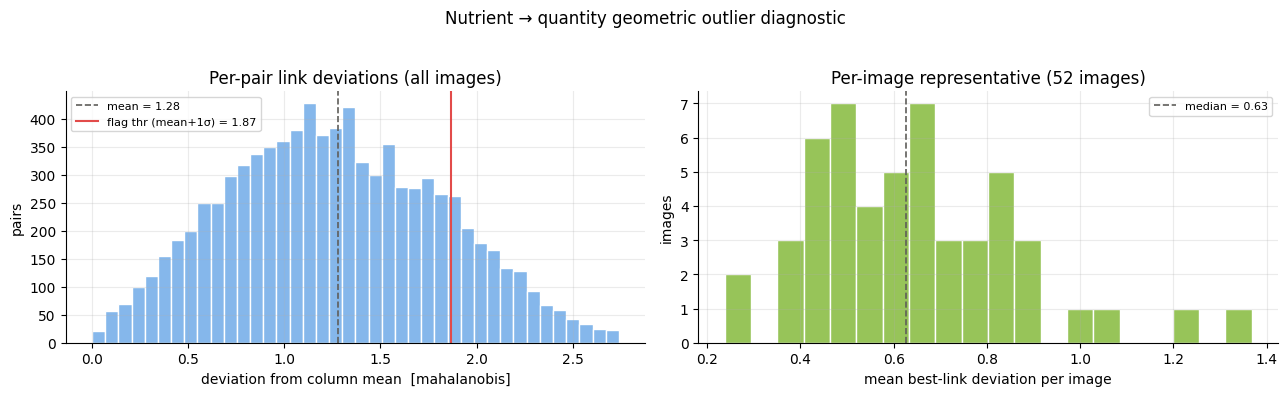

### Displacement outlier diagnostic — disp_v1

- OCR `paddleocr` · classifier `rule_based` (cpu) · method `mahalanobis` · columns `enricher`
- images 57 · ok 52 · degenerate 5 · errors 0
- pair flag thr (mean+1σ) = **1.865** → flagged pairs **1445**
- link miss thr = **1.117** → likely-missing links **115**

**Most suspect links (top 10 by best-link deviation)**

,image_id,nutrient,best_quantity,column,dx,dy,best_deviation,likely_missing
84,9.jpeg,vitamin czuachten,60,1,175.0,49.5,2.3597,1
382,64.png,pantothenic acid,80,0,889.0,-277.0,2.2741,1
545,113.jpeg,davongesattigte fettsauren,11,0,-169.5,-136.5,2.2151,1
303,53.png,vitamin b6vitamine b6,0.35,3,1687.0,-14.0,2.1057,1
295,53.png,vitamin b6vitamine b6,0.21,2,2199.5,-32.5,2.1057,1
674,121.jpeg,eiweibriegelmitkokos-mandel-geschmackundkokosraspeln,12,1,364.0,206.5,2.0857,1
271,51.png,vitamin b1,0.21,2,2221.0,93.5,2.0846,1
149,20.png,caffeine (from guarana extract powder,6.7,1,664.0,589.0,2.0263,1
665,121.jpeg,eiweibriegelmitkokos-mandel-geschmackundkokosraspeln,151,0,231.5,169.0,1.9919,1
621,118.jpeg,davon gesattigtefettsauren,275,1,462.1,-103.0,1.9367,1


**Per-image — worst first (the histogram source)**

,image_id,n_nutrients,n_quantities,n_columns,n_pairs,mean_pair_dev,n_links,n_links_missing,representative
5,9.jpeg,3,3,2,9,1.3733,6,4,1.3676
38,106.png,10,2,1,20,1.3130,10,6,1.2176
19,53.png,8,17,4,136,1.3005,32,12,1.0763
18,51.png,8,16,3,128,1.3059,24,9,1.0101
20,56.jpeg,2,8,2,16,1.2843,4,0,0.9132
2,4.png,47,5,1,235,1.3101,47,18,0.8958
53,121.jpeg,9,18,2,162,1.2317,18,4,0.8697
8,17.png,4,7,3,28,1.1706,12,3,0.8408
16,41.png,7,5,1,35,1.2870,7,2,0.8362
54,201.jpeg,6,16,2,96,1.2969,12,2,0.8190


[Snippet 3] displacement diagnostic complete.


In [16]:
# ════════════════════════════════════════════════════════════════════════
# SNIPPET 3 — Nutrient→Quantity geometric outlier diagnostic (supervisor follow-up)
# Ablation redo | Zero-Shot Nutrient & Quantity Association | M. Hamada
# ════════════════════════════════════════════════════════════════════════
"""Per-image geometric outlier check on nutrient→quantity links, reusing the
Snippet-2 front-end (OCR · corrector · classifier · enricher).

For each image: form every displacement vector d = q_centroid - n_centroid,
average them PER QUANTITY COLUMN to one mean vector v_bar, then score each
pair by how far it deviates from v_bar. Large deviation == the nutrient's
nearest-to-template quantity sits in the wrong row, which is what happens
when OCR DROPS the quantity that belonged to it -> an interpretable
missing-value / wrong-link signal. Diagnostic only; no 4F-F1 is computed.

Deviation = variance-floored diagonal Mahalanobis (a z-score in x and a
z-score in y, combined). Inside one column dx is ~constant, so the full 2x2
covariance is near-singular; the diagonal+floor form is the numerically safe
version of 'deviation from the average vector'. method='euclidean' gives the
plain ||d - v_bar|| instead."""

import math
from src.utils.token_enricher import TokenEnricher

displacement_config = {
    "deviation_method":  "mahalanobis",   # "mahalanobis" (diag, var-floored) | "euclidean"
    "min_pairs_for_cov": 4,               # below this in a column -> euclidean fallback
    "var_floor_frac":    0.15,            # variance floor as fraction of median token height
    "flag_k":            1.0,             # flag if deviation > mean + k*std (global)
    "column_source":     "enricher",      # "enricher" (column_id) | "cluster" (cx gap)
    "cluster_gap_frac":  1.5,             # cx gap (x median qty width) to split columns
    "nutrient_label":    "NUTRIENT",
    "quantity_label":    "QUANTITY",
    "cy_rule":      "same_or_lower",   # "same_or_lower" | "same_or_lower_bounded" | "band"
    "same_cy_tol":  0.6,    # "same cy" jitter band = same_cy_tol × median token height
    "row_factor":   0.8,    # downward cap (bounded mode only), × median token height
    "forward_only": False,  # also require quantity to the RIGHT of the nutrient (Δcx > 0)
}



# ── token helpers ──────────────────────────────────────────────────────────
def _disp_xy(t):
    cx, cy = t.get("cx"), t.get("cy")
    if cx is None: cx = (float(t.get("x1", 0)) + float(t.get("x2", 0))) / 2.0
    if cy is None: cy = (float(t.get("y1", 0)) + float(t.get("y2", 0))) / 2.0
    return float(cx), float(cy)

def _disp_h(t): return max(float(t.get("y2", 0)) - float(t.get("y1", 0)), 1.0)
def _disp_w(t): return max(float(t.get("x2", 0)) - float(t.get("x1", 0)), 1.0)
def _disp_text(t): return (str(t.get("norm") or t.get("token") or "")).strip(" '\"*.,[]()/|")

def _disp_columns(quantities, cfg):
    if cfg["column_source"] == "enricher" and all(q.get("column_id") is not None for q in quantities):
        groups = defaultdict(list)
        for q in quantities:
            groups[q["column_id"]].append(q)
        return list(groups.values())
    qs = sorted(quantities, key=lambda q: _disp_xy(q)[0])
    gap = cfg["cluster_gap_frac"] * float(np.median([_disp_w(q) for q in qs]))
    cols, cur = [], [qs[0]]
    for prev, q in zip(qs, qs[1:]):
        (cols.append(cur) or cur.clear() or cur.append(q)) if _disp_xy(q)[0] - _disp_xy(prev)[0] > gap else cur.append(q)
    cols.append(cur)
    return cols


# ── per-image core ─────────────────────────────────────────────────────────
def analyze_displacement_image(image_id, enriched, cfg):
    nutrients  = [t for t in enriched if t.get("label") == cfg["nutrient_label"]]
    quantities = [t for t in enriched if t.get("label") == cfg["quantity_label"]]
    summary = {"image_id": image_id, "status": "ok",
               "n_nutrients": len(nutrients), "n_quantities": len(quantities),
               "n_columns": 0, "n_pairs": 0, "mean_pair_dev": float("nan"),
               "max_pair_dev": float("nan"), "n_links": 0, "n_links_missing": 0,
               "representative": float("nan"), "method": cfg["deviation_method"]}
    if len(nutrients) == 0 or len(quantities) < 2:
        summary["status"] = "degenerate"
        return [], [], summary

    med_h = float(np.median([_disp_h(t) for t in nutrients + quantities]))
    floor = max(1.0, cfg["var_floor_frac"] * med_h)
    columns = _disp_columns(quantities, cfg)
    summary["n_columns"] = len(columns)

    pair_rows, best = [], {}
    for col_idx, qs in enumerate(columns):
        disps = np.array([[_disp_xy(q)[0] - _disp_xy(n)[0], _disp_xy(q)[1] - _disp_xy(n)[1]]
                          for n in nutrients for q in qs], dtype=float)
        if len(disps) == 0:
            continue
        vbar = disps.mean(axis=0)
        use_maha = cfg["deviation_method"] == "mahalanobis" and len(disps) >= cfg["min_pairs_for_cov"]
        if use_maha:
            sx = max(float(disps[:, 0].std(ddof=1)), floor)
            sy = max(float(disps[:, 1].std(ddof=1)), floor)
            method_used = "mahalanobis"
        else:
            sx = sy = None
            method_used = "euclidean"
        for n in nutrients:
            nx, ny = _disp_xy(n)
            for q in qs:
                qx, qy = _disp_xy(q)
                dx, dy = qx - nx, qy - ny
                dev = (math.hypot((dx - vbar[0]) / sx, (dy - vbar[1]) / sy)
                       if method_used == "mahalanobis"
                       else math.hypot(dx - vbar[0], dy - vbar[1]) / med_h)
                pair_rows.append({"image_id": image_id, "nutrient": _disp_text(n),
                                  "quantity": _disp_text(q), "column": col_idx,
                                  "dx": round(dx, 1), "dy": round(dy, 1),
                                  "deviation": round(dev, 4), "method": method_used})
                key = (id(n), col_idx)
                if key not in best or dev < best[key]["dev"]:
                    best[key] = {"dev": dev, "q": q, "dx": dx, "dy": dy}

    if not pair_rows:
        summary["status"] = "degenerate"
        return [], [], summary

    devs = np.array([r["deviation"] for r in pair_rows], dtype=float)
    summary.update(n_pairs=len(pair_rows),
                   mean_pair_dev=round(float(devs.mean()), 4),
                   max_pair_dev=round(float(devs.max()), 4))

    link_rows = []
    for (nid, col_idx), b in best.items():
        n = next(t for t in nutrients if id(t) == nid)
        link_rows.append({"image_id": image_id, "nutrient": _disp_text(n), "column": col_idx,
                          "best_quantity": _disp_text(b["q"]), "dx": round(b["dx"], 1),
                          "dy": round(b["dy"], 1), "best_deviation": round(b["dev"], 4),
                          "method": summary["method"]})
    summary["n_links"] = len(link_rows)
    summary["representative"] = round(float(np.mean([l["best_deviation"] for l in link_rows])), 4)
    return pair_rows, link_rows, summary


# ── driver (mirrors run_pipeline_experiment; separate from the F1 ablation) ──
@dataclass
class DisplacementRun:
    label: str
    out_dir: Path
    classifier_key: str
    classifier_device: str
    n_images: int
    n_ok: int
    n_degenerate: int
    n_errors: int
    pair_thr: float
    link_thr: float
    per_image: Any
    links: Any
    pairs: Any


def run_displacement_diagnostic(*, ocr_engine="paddleocr", classifier_key="rule_based",
                                label="v1", cfg_override=None, display_result=True) -> DisplacementRun:
    cfg = {**displacement_config, **(cfg_override or {})}
    K = cfg["flag_k"]
    out_dir = OUTPUT_DIR / f"disp_{_slug(label)}"
    out_dir.mkdir(parents=True, exist_ok=True)

    ocr_fn       = build_ocr_engine(ocr_engine)
    corrector_fn = build_corrector(ocr_engine)
    classifier   = build_classifier(classifier_key)
    enricher     = TokenEnricher()
    images       = list_images(RAW_DIR, limit=ablation_config["debug"]["limit_images"])
    logger.info("[disp_%s] %d images · classifier=%s on %s · method=%s",
                _slug(label), len(images), classifier_key, classifier.device, cfg["deviation_method"])

    all_pairs, all_links, summaries = [], [], []
    n_ok = n_deg = n_err = 0
    for i, img in enumerate(images, 1):
        image_id = img.stem + img.suffix.lower()
        try:
            tokens          = _ensure_cx_cy(ocr_fn(str(img)))
            corrected, _    = corrector_fn(tokens)
            corrected       = _ensure_cx_cy(corrected)
            labeled         = classifier.classify_all(corrected)
            enriched        = enricher.enrich(labeled)
            pairs, links, s = analyze_displacement_image(image_id, enriched, cfg)
            all_pairs += pairs; all_links += links; summaries.append(s)
            n_ok += (s["status"] == "ok"); n_deg += (s["status"] == "degenerate")
        except Exception as e:
            logger.error("[disp] %s failed: %s", image_id, e)
            n_err += 1
            if ablation_config["debug"]["strict_mode"]:
                raise
        if i % 10 == 0 or i == len(images):
            logger.info("[disp_%s]   %d/%d (ok %d · degenerate %d · errors %d)",
                        _slug(label), i, len(images), n_ok, n_deg, n_err)

    pair_devs = np.array([p["deviation"] for p in all_pairs], dtype=float)
    link_devs = np.array([l["best_deviation"] for l in all_links], dtype=float)
    pair_thr = float(pair_devs.mean() + K * pair_devs.std()) if len(pair_devs) else float("nan")
    link_thr = float(link_devs.mean() + K * link_devs.std()) if len(link_devs) else float("nan")

    img_mean = {s["image_id"]: s["mean_pair_dev"] for s in summaries}
    for p in all_pairs:
        p["is_flagged"] = int(p["deviation"] > pair_thr)
        m = img_mean.get(p["image_id"], float("nan"))
        p["gt_image_mean"] = int(p["deviation"] > m) if m == m else 0
    for l in all_links:
        l["likely_missing"] = int(l["best_deviation"] > link_thr)
    by_img = defaultdict(list)
    for l in all_links:
        by_img[l["image_id"]].append(l)
    for s in summaries:
        s["n_links_missing"] = sum(x["likely_missing"] for x in by_img.get(s["image_id"], []))
    all_pairs.sort(key=lambda p: p["deviation"], reverse=True)
    for i, p in enumerate(all_pairs, 1):
        p["rank"] = i

    pairs_df = pd.DataFrame(all_pairs)
    links_df = (pd.DataFrame(all_links).sort_values("best_deviation", ascending=False)
                if all_links else pd.DataFrame())
    img_df   = pd.DataFrame(summaries)
    pairs_df.to_csv(out_dir / "displacement_pairs.csv", index=False)
    links_df.to_csv(out_dir / "displacement_links.csv", index=False)
    img_df.to_csv(out_dir / "displacement_per_image.csv", index=False)

    # ── histogram: (A) pooled pair deviations  (B) one representative / image ──
    reps = [s["representative"] for s in summaries
            if s["status"] == "ok" and s["representative"] == s["representative"]]
    try:
        fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4))
        if len(pair_devs):
            hi = float(np.percentile(pair_devs, 99))
            axA.hist(pair_devs, bins=40, range=(0, max(hi, pair_thr * 1.05)),
                     color="#85B7EB", edgecolor="white")
            axA.axvline(float(pair_devs.mean()), color="#5F5E5A", ls="--", lw=1.2,
                        label=f"mean = {pair_devs.mean():.2f}")
            axA.axvline(pair_thr, color="#E24B4A", lw=1.5,
                        label=f"flag thr (mean+{K:g}\u03c3) = {pair_thr:.2f}")
            axA.legend(fontsize=8)
        axA.set_title("Per-pair link deviations (all images)")
        axA.set_xlabel(f"deviation from column mean  [{cfg['deviation_method']}]")
        axA.set_ylabel("pairs")
        if reps:
            axB.hist(reps, bins=20, color="#97C459", edgecolor="white")
            axB.axvline(float(np.median(reps)), color="#5F5E5A", ls="--", lw=1.2,
                        label=f"median = {np.median(reps):.2f}")
            axB.legend(fontsize=8)
        axB.set_title(f"Per-image representative ({len(reps)} images)")
        axB.set_xlabel("mean best-link deviation per image"); axB.set_ylabel("images")
        fig.suptitle("Nutrient \u2192 quantity geometric outlier diagnostic")
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        fig.savefig(out_dir / "displacement_histogram.png", dpi=150)
        plt.show()
    except Exception as e:
        logger.warning("displacement histogram skipped: %s", e)

    if display_result:
        n_flag = int(pairs_df["is_flagged"].sum()) if len(pairs_df) else 0
        n_miss = int(links_df["likely_missing"].sum()) if len(links_df) else 0
        display(Markdown(f"### Displacement outlier diagnostic — disp_{_slug(label)}"))
        display(Markdown(
            f"- OCR `{ocr_engine}` · classifier `{classifier_key}` ({classifier.device}) "
            f"· method `{cfg['deviation_method']}` · columns `{cfg['column_source']}`\n"
            f"- images {len(images)} · ok {n_ok} · degenerate {n_deg} · errors {n_err}\n"
            f"- pair flag thr (mean+{K:g}σ) = **{pair_thr:.3f}** → flagged pairs **{n_flag}**\n"
            f"- link miss thr = **{link_thr:.3f}** → likely-missing links **{n_miss}**"))
        if len(links_df):
            display(Markdown("**Most suspect links (top 10 by best-link deviation)**"))
            display(links_df.head(10)[["image_id", "nutrient", "best_quantity",
                                       "column", "dx", "dy", "best_deviation", "likely_missing"]])
        if len(img_df):
            display(Markdown("**Per-image — worst first (the histogram source)**"))
            display(img_df[img_df["status"] == "ok"]
                    .sort_values("representative", ascending=False)
                    [["image_id", "n_nutrients", "n_quantities", "n_columns",
                      "n_pairs", "mean_pair_dev", "n_links", "n_links_missing", "representative"]])

    return DisplacementRun(label=label, out_dir=out_dir, classifier_key=classifier_key,
                           classifier_device=classifier.device, n_images=len(images),
                           n_ok=n_ok, n_degenerate=n_deg, n_errors=n_err,
                           pair_thr=pair_thr, link_thr=link_thr,
                           per_image=img_df, links=links_df, pairs=pairs_df)


# ── run it ──────────────────────────────────────────────────────────────────
disp_run = run_displacement_diagnostic(ocr_engine="paddleocr",
                                       classifier_key="rule_based", label="v1")
print("[Snippet 3] displacement diagnostic complete.")

In [18]:
# ── How many are above vs at-or-below the average deviation ──
def split_at_mean(values, name):
    v = np.asarray(values, dtype=float); v = v[~np.isnan(v)]
    if len(v) == 0:
        print(f"{name}: (empty)"); return
    m = float(v.mean())
    above = int((v > m).sum()); below = int((v <= m).sum())
    print(f"{name}  (n={len(v)}, mean={m:.4f})")
    print(f"    >  mean : {above:>5}  ({100*above/len(v):5.1f}%)")
    print(f"    <= mean : {below:>5}  ({100*below/len(v):5.1f}%)")

# global average across the whole test set
split_at_mean(disp_run.pairs["deviation"],      "PAIRS  (all nutrient x quantity candidates)")
split_at_mean(disp_run.links["best_deviation"], "LINKS  (best quantity per nutrient per column)")

# per-image rule: each pair vs ITS OWN image's average (what the supervisor described)
gm = disp_run.pairs["gt_image_mean"]
print(f"\nPER-IMAGE rule (pair vs its own image's average):"
      f"  > mean = {int(gm.sum())}   <= mean = {int((gm == 0).sum())}   of {len(gm)}")

PAIRS  (all nutrient x quantity candidates)  (n=8645, mean=1.2807)
    >  mean :  4137  ( 47.9%)
    <= mean :  4508  ( 52.1%)
LINKS  (best quantity per nutrient per column)  (n=710, mean=0.6637)
    >  mean :   292  ( 41.1%)
    <= mean :   418  ( 58.9%)

PER-IMAGE rule (pair vs its own image's average):  > mean = 4086   <= mean = 4559   of 8645


In [19]:
# ── Per-image: pairs above vs at-or-below THAT image's own average deviation ──
def per_image_mean_split(pairs_df):
    rows = []
    for img, g in pairs_df.groupby("image_id", sort=False):
        above = int(g["gt_image_mean"].sum())          # deviation >  image mean
        below = int((g["gt_image_mean"] == 0).sum())   # deviation <= image mean
        rows.append({"image_id": img, "n_pairs": len(g),
                     "above_mean": above, "at_or_below_mean": below,
                     "pct_above": round(100 * above / len(g), 1)})
    df = pd.DataFrame(rows)
    tot = len(pairs_df); a = int(pairs_df["gt_image_mean"].sum()); b = tot - a
    print(f"PER-IMAGE rule (each pair vs its own image's average deviation)")
    print(f"  total pairs    : {tot}")
    print(f"  >  image mean  : {a:>5}  ({100*a/tot:5.1f}%)")
    print(f"  <= image mean  : {b:>5}  ({100*b/tot:5.1f}%)")
    print(f"  images         : {len(df)}")
    return df.sort_values("pct_above", ascending=False).reset_index(drop=True)

split_df = per_image_mean_split(disp_run.pairs)
display(split_df)
split_df.to_csv(disp_run.out_dir / "displacement_per_image_mean_split.csv", index=False)

PER-IMAGE rule (each pair vs its own image's average deviation)
  total pairs    : 8645
  >  image mean  :  4086  ( 47.3%)
  <= image mean  :  4559  ( 52.7%)
  images         : 52


,image_id,n_pairs,above_mean,at_or_below_mean,pct_above
0,110.jpeg,18,12,6,66.7
1,106.png,20,13,7,65.0
2,90.png,135,78,57,57.8
3,8.png,48,27,21,56.2
4,41.png,35,19,16,54.3
5,4.png,235,126,109,53.6
6,82.jpeg,15,8,7,53.3
7,6.png,36,19,17,52.8
8,63.png,220,116,104,52.7
9,57.jpeg,40,21,19,52.5


In [20]:
# ── Per-image average displacement vector + larger/smaller counts ──
def per_image_avg_vector(pairs_df):
    rows = []
    for img, g in pairs_df.groupby("image_id", sort=False):
        dx = g["dx"].to_numpy(float); dy = g["dy"].to_numpy(float)
        avg_dx, avg_dy = float(dx.mean()), float(dy.mean())   # the average vector
        avg_mag = math.hypot(avg_dx, avg_dy)                  # its length
        mag = np.hypot(dx, dy)                                # each vector's length
        larger  = int((mag >  avg_mag).sum())
        smaller = int((mag <= avg_mag).sum())
        rows.append({"image_id": img, "n_vectors": len(g),
                     "avg_dcx": round(avg_dx, 1), "avg_dcy": round(avg_dy, 1),
                     "avg_magnitude": round(avg_mag, 1),
                     "larger": larger, "smaller_or_equal": smaller})
    return pd.DataFrame(rows)

avg_df = per_image_avg_vector(disp_run.pairs)

print(f"{'image':<12} {'avg Δcx':>9} {'avg Δcy':>9} {'|avg|':>8} {'larger':>7} {'<=avg':>6} {'n':>5}")
print("-" * 60)
for _, r in avg_df.iterrows():
    print(f"{r['image_id']:<12} {r['avg_dcx']:>9.1f} {r['avg_dcy']:>9.1f} "
          f"{r['avg_magnitude']:>8.1f} {r['larger']:>7} {r['smaller_or_equal']:>6} {r['n_vectors']:>5}")

display(avg_df)
avg_df.to_csv(disp_run.out_dir / "displacement_avg_vector_per_image.csv", index=False)

image          avg Δcx   avg Δcy    |avg|  larger  <=avg     n
------------------------------------------------------------
34.png           622.1     -37.3    623.2     713    167   880
101.png         1051.7    -133.2   1060.1      79     21   100
107.png         1117.3     -60.3   1118.9      72     18    90
59.png          1228.9     -85.0   1231.9     137    115   252
121.jpeg         484.7      26.1    485.4     101     61   162
27.png           938.0      94.5    942.7     118     26   144
20.png          1428.6     -27.1   1428.9     719    457  1176
42.png          1174.4    -131.3   1181.8      82     22   104
102.png         1141.8    -102.4   1146.4      89     73   162
109.jpeg         308.7     -32.0    310.3      56     16    72
115.png          698.7    -131.4    710.9      66     15    81
45_2.png        1159.1     140.3   1167.6      29     13    42
12.png           865.8     -20.0    866.0      76     43   119
26.png          1115.4     -35.0   1115.9      31     18 

,image_id,n_vectors,avg_dcx,avg_dcy,avg_magnitude,larger,smaller_or_equal
0,34.png,880,622.1,-37.3,623.2,713,167
1,101.png,100,1051.7,-133.2,1060.1,79,21
2,107.png,90,1117.3,-60.3,1118.9,72,18
3,59.png,252,1228.9,-85.0,1231.9,137,115
4,121.jpeg,162,484.7,26.1,485.4,101,61
5,27.png,144,938.0,94.5,942.7,118,26
6,20.png,1176,1428.6,-27.1,1428.9,719,457
7,42.png,104,1174.4,-131.3,1181.8,82,22
8,102.png,162,1141.8,-102.4,1146.4,89,73
9,109.jpeg,72,308.7,-32.0,310.3,56,16


In [21]:
def analyze_displacement_image(image_id, enriched, cfg):
    nutrients  = [t for t in enriched if t.get("label") == cfg["nutrient_label"]]
    quantities = [t for t in enriched if t.get("label") == cfg["quantity_label"]]
    summary = {"image_id": image_id, "status": "ok",
               "n_nutrients": len(nutrients), "n_quantities": len(quantities),
               "n_columns": 0, "n_pairs": 0, "mean_pair_dev": float("nan"),
               "max_pair_dev": float("nan"), "n_links": 0, "n_links_missing": 0,
               "n_nutrients_no_candidate": 0,
               "representative": float("nan"), "method": cfg["deviation_method"]}
    if len(nutrients) == 0 or len(quantities) < 2:
        summary["status"] = "degenerate"
        return [], [], summary

    med_h = float(np.median([_disp_h(t) for t in nutrients + quantities]))
    floor = max(1.0, cfg["var_floor_frac"] * med_h)
    columns = _disp_columns(quantities, cfg)
    summary["n_columns"] = len(columns)

    gate     = cfg.get("candidate_gate", {})
    cy_rule  = gate.get("cy_rule", "same_or_lower")
    same_tol = gate.get("same_cy_tol", 0.6) * med_h
    row_tol  = gate.get("row_factor", 0.8) * med_h
    fwd_only = gate.get("forward_only", False)

    def _cy_ok(dy):
        # dy = q.cy - n.cy ; larger cy = lower on the page
        if cy_rule == "band":                 # symmetric row band (old behaviour)
            return abs(dy) <= row_tol
        if cy_rule == "same_or_lower_bounded": # same line or up to one row below
            return -same_tol <= dy <= row_tol
        return dy >= -same_tol                 # "same_or_lower": same line or anywhere below

    pair_rows, best = [], {}
    for col_idx, qs in enumerate(columns):
        cand = []
        for n in nutrients:
            nx, ny = _disp_xy(n)
            for q in qs:
                qx, qy = _disp_xy(q)
                dx, dy = qx - nx, qy - ny
                if not _cy_ok(dy):            # quantity above the nutrient -> impossible link
                    continue
                if fwd_only and dx <= 0:      # quantity must be right of the name
                    continue
                cand.append((n, q, dx, dy))
        if not cand:
            continue

        disps = np.array([[c[2], c[3]] for c in cand], dtype=float)
        vbar = disps.mean(axis=0)
        use_maha = cfg["deviation_method"] == "mahalanobis" and len(disps) >= cfg["min_pairs_for_cov"]
        if use_maha:
            sx = max(float(disps[:, 0].std(ddof=1)), floor)
            sy = max(float(disps[:, 1].std(ddof=1)), floor)
            method_used = "mahalanobis"
        else:
            sx = sy = None
            method_used = "euclidean"

        for (n, q, dx, dy) in cand:
            dev = (math.hypot((dx - vbar[0]) / sx, (dy - vbar[1]) / sy)
                   if method_used == "mahalanobis"
                   else math.hypot(dx - vbar[0], dy - vbar[1]) / med_h)
            pair_rows.append({"image_id": image_id, "nutrient": _disp_text(n),
                              "quantity": _disp_text(q), "column": col_idx,
                              "dx": round(dx, 1), "dy": round(dy, 1),
                              "deviation": round(dev, 4), "method": method_used})
            key = (id(n), col_idx)
            if key not in best or dev < best[key]["dev"]:
                best[key] = {"dev": dev, "q": q, "dx": dx, "dy": dy}

    if not pair_rows:
        summary["status"] = "degenerate"
        return [], [], summary

    devs = np.array([r["deviation"] for r in pair_rows], dtype=float)
    summary.update(n_pairs=len(pair_rows),
                   mean_pair_dev=round(float(devs.mean()), 4),
                   max_pair_dev=round(float(devs.max()), 4))

    nut_ids_with_cand = {nid for (nid, _c) in best.keys()}
    summary["n_nutrients_no_candidate"] = sum(1 for n in nutrients if id(n) not in nut_ids_with_cand)

    link_rows = []
    for (nid, col_idx), b in best.items():
        n = next(t for t in nutrients if id(t) == nid)
        link_rows.append({"image_id": image_id, "nutrient": _disp_text(n), "column": col_idx,
                          "best_quantity": _disp_text(b["q"]), "dx": round(b["dx"], 1),
                          "dy": round(b["dy"], 1), "best_deviation": round(b["dev"], 4),
                          "method": summary["method"]})
    summary["n_links"] = len(link_rows)
    summary["representative"] = round(float(np.mean([l["best_deviation"] for l in link_rows])), 4)
    return pair_rows, link_rows, summary

In [17]:
def analyze_displacement_image(image_id, enriched, cfg):
    nutrients  = [t for t in enriched if t.get("label") == cfg["nutrient_label"]]
    quantities = [t for t in enriched if t.get("label") == cfg["quantity_label"]]
    summary = {"image_id": image_id, "status": "ok",
               "n_nutrients": len(nutrients), "n_quantities": len(quantities),
               "n_columns": 0, "n_pairs": 0, "mean_pair_dev": float("nan"),
               "max_pair_dev": float("nan"), "n_links": 0, "n_links_missing": 0,
               "n_nutrients_no_candidate": 0,
               "representative": float("nan"), "method": cfg["deviation_method"]}
    if len(nutrients) == 0 or len(quantities) < 2:
        summary["status"] = "degenerate"
        return [], [], summary

    med_h = float(np.median([_disp_h(t) for t in nutrients + quantities]))
    floor = max(1.0, cfg["var_floor_frac"] * med_h)
    columns = _disp_columns(quantities, cfg)
    summary["n_columns"] = len(columns)

    gate     = cfg.get("candidate_gate", {})
    cy_rule  = gate.get("cy_rule", "same_or_lower")
    same_tol = gate.get("same_cy_tol", 0.6) * med_h
    row_tol  = gate.get("row_factor", 0.8) * med_h
    fwd_only = gate.get("forward_only", False)

    def _cy_ok(dy):
        # dy = q.cy - n.cy ; larger cy = lower on the page
        if cy_rule == "band":                 # symmetric row band (old behaviour)
            return abs(dy) <= row_tol
        if cy_rule == "same_or_lower_bounded": # same line or up to one row below
            return -same_tol <= dy <= row_tol
        return dy >= -same_tol                 # "same_or_lower": same line or anywhere below

    pair_rows, best = [], {}
    for col_idx, qs in enumerate(columns):
        cand = []
        for n in nutrients:
            nx, ny = _disp_xy(n)
            for q in qs:
                qx, qy = _disp_xy(q)
                dx, dy = qx - nx, qy - ny
                if not _cy_ok(dy):            # quantity above the nutrient -> impossible link
                    continue
                if fwd_only and dx <= 0:      # quantity must be right of the name
                    continue
                cand.append((n, q, dx, dy))
        if not cand:
            continue

        disps = np.array([[c[2], c[3]] for c in cand], dtype=float)
        vbar = disps.mean(axis=0)
        use_maha = cfg["deviation_method"] == "mahalanobis" and len(disps) >= cfg["min_pairs_for_cov"]
        if use_maha:
            sx = max(float(disps[:, 0].std(ddof=1)), floor)
            sy = max(float(disps[:, 1].std(ddof=1)), floor)
            method_used = "mahalanobis"
        else:
            sx = sy = None
            method_used = "euclidean"

        for (n, q, dx, dy) in cand:
            dev = (math.hypot((dx - vbar[0]) / sx, (dy - vbar[1]) / sy)
                   if method_used == "mahalanobis"
                   else math.hypot(dx - vbar[0], dy - vbar[1]) / med_h)
            pair_rows.append({"image_id": image_id, "nutrient": _disp_text(n),
                              "quantity": _disp_text(q), "column": col_idx,
                              "dx": round(dx, 1), "dy": round(dy, 1),
                              "deviation": round(dev, 4), "method": method_used})
            key = (id(n), col_idx)
            if key not in best or dev < best[key]["dev"]:
                best[key] = {"dev": dev, "q": q, "dx": dx, "dy": dy}

    if not pair_rows:
        summary["status"] = "degenerate"
        return [], [], summary

    devs = np.array([r["deviation"] for r in pair_rows], dtype=float)
    summary.update(n_pairs=len(pair_rows),
                   mean_pair_dev=round(float(devs.mean()), 4),
                   max_pair_dev=round(float(devs.max()), 4))

    nut_ids_with_cand = {nid for (nid, _c) in best.keys()}
    summary["n_nutrients_no_candidate"] = sum(1 for n in nutrients if id(n) not in nut_ids_with_cand)

    link_rows = []
    for (nid, col_idx), b in best.items():
        n = next(t for t in nutrients if id(t) == nid)
        link_rows.append({"image_id": image_id, "nutrient": _disp_text(n), "column": col_idx,
                          "best_quantity": _disp_text(b["q"]), "dx": round(b["dx"], 1),
                          "dy": round(b["dy"], 1), "best_deviation": round(b["dev"], 4),
                          "method": summary["method"]})
    summary["n_links"] = len(link_rows)
    summary["representative"] = round(float(np.mean([l["best_deviation"] for l in link_rows])), 4)
    return pair_rows, link_rows, summary


image          avg Δcx   avg Δcy    |avg|  larger  <=avg      n
--------------------------------------------------------------
1.png           1660.6     212.2   1674.1       8      3     11
2.png           1759.9     339.9   1792.4      32     28     60
4.png           2041.2     134.7   2045.6      72     67    139
6.png           1384.1     349.3   1427.5      10     11     21
8.png           1028.1     298.5   1070.5      13      9     22
9.jpeg           136.2      20.8    137.8       3      5      8
12.png           903.8     243.7    936.0      32     32     64
17.png          1461.0     232.9   1479.5       9     10     19
20.png          1412.3     456.2   1484.2     349    252    601
26.png          1121.5     195.4   1138.4      12     11     23
27.png           963.7     488.6   1080.5      41     47     88
30.png           942.2     292.1    986.5      42     32     74
33.png          1018.3     513.5   1140.4     106     66    172
34.png           644.6     580.7    867.

### Displacement diagnostic — disp_v1  (OCR `paddleocr` · classifier `rule_based` · gate `same_or_lower`)

,image_id,n_nutrients,n_quantities,n_columns,n_vectors,avg_dcx,avg_dcy,avg_magnitude,larger,smaller_or_equal,n_links,n_links_missing,representative
0,1.png,4,5,1,11,1660.6,212.2,1674.1,8,3,4,1,1.1433
1,2.png,8,12,2,60,1759.9,339.9,1792.4,32,28,16,6,1.0418
2,4.png,47,5,1,139,2041.2,134.7,2045.6,72,67,45,16,1.0537
3,6.png,6,6,1,21,1384.1,349.3,1427.5,10,11,6,1,0.7933
4,8.png,8,6,1,22,1028.1,298.5,1070.5,13,9,6,1,0.8056
5,9.jpeg,3,3,2,8,136.2,20.8,137.8,3,5,6,1,1.3723
6,12.png,7,17,2,64,903.8,243.7,936.0,32,32,14,2,0.9230
7,17.png,4,7,3,19,1461.0,232.9,1479.5,9,10,10,1,0.8743
8,20.png,24,49,2,601,1412.3,456.2,1484.2,349,252,45,6,0.7025
9,26.png,7,7,1,23,1121.5,195.4,1138.4,12,11,6,1,0.8725


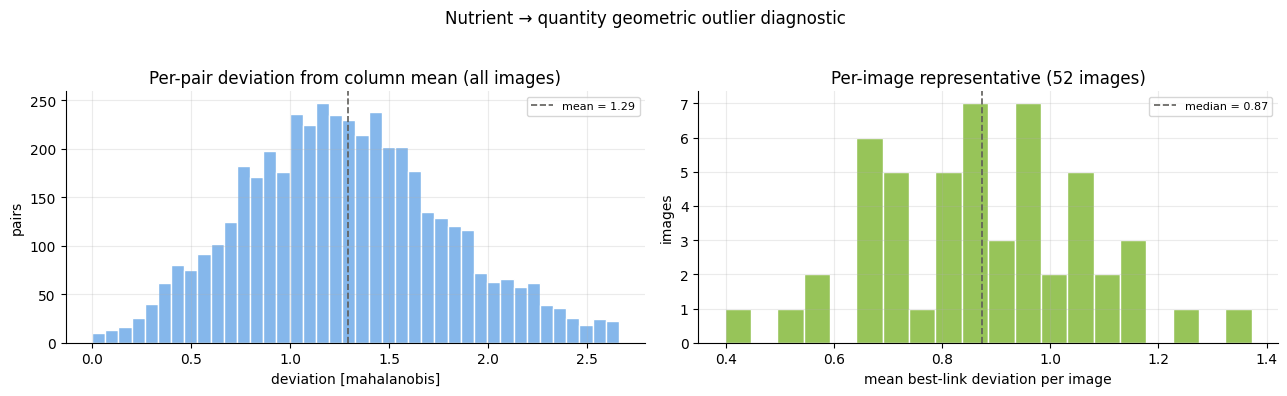


Saved: C:\Users\MSAEI\OneDrive\Desktop\zero_shot_nutrient_association\results\ablation_redo\disp_v1  (displacement_per_image.csv · pairs · links · histogram.png)
[Snippet 3] done.


In [23]:
# ════════════════════════════════════════════════════════════════════════
# SNIPPET 3 — Per-image average displacement vector + outlier diagnostic
# (supervisor follow-up) · run AFTER Snippets 1 & 2
# ════════════════════════════════════════════════════════════════════════
"""
For each label image:
  1. Build a displacement vector  d = (q.cx - n.cx, q.cy - n.cy)  from each
     NUTRIENT to each QUANTITY — but keep the pair ONLY if the quantity is on
     the same line as the nutrient OR below it (never above).
     Sign: origin is top-left, so larger cy = lower on the page; the gate is
     dy >= -tol  ==  "same line or lower".
  2. Average all kept vectors  ->  ONE average vector (avg_dcx, avg_dcy) per image.
  3. Count vectors LARGER vs SMALLER-OR-EQUAL than that average vector (by length).
  4. (diagnostic) score each pair by deviation from its column's mean vector and
     flag a nutrient's best link as 'likely_missing' when even its closest
     candidate is an outlier — the interpretable OCR-drop signal.
Diagnostic only — no 4F-F1 is computed; nothing here touches your ablation numbers.
"""

import math
from types import SimpleNamespace
from src.utils.token_enricher import TokenEnricher

# ── CONFIG (edit here) ──────────────────────────────────────────────────────
displacement_config = {
    "ocr_engine":      "paddleocr",
    "classifier_key":  "rule_based",        # "embedding" | "rule_based" | "gliner"
    "label":           "v1",        # output -> results/.../disp_<label>/

    # candidate gate: which (nutrient, quantity) pairs may form a vector
    "cy_rule":         "same_or_lower",    # "same_or_lower" | "same_or_lower_bounded" | "band"
    "same_cy_tol":     0.6,   # "same line" jitter band = same_cy_tol x median token height
    "row_factor":      0.8,   # downward cap (bounded/band only) x median token height
    "forward_only":    False, # also require quantity to the RIGHT of the name (dx > 0)

    # deviation scoring (missing-link diagnostic)
    "deviation_method":  "mahalanobis",    # "mahalanobis" (diag, var-floored) | "euclidean"
    "min_pairs_for_cov": 4,
    "var_floor_frac":    0.15,
    "flag_k":            1.0,

    # quantity column grouping (per-column averaging)
    "column_source":   "enricher",         # "enricher" (column_id) | "cluster" (cx gap)
    "cluster_gap_frac": 1.5,

    "nutrient_label":  "NUTRIENT",
    "quantity_label":  "QUANTITY",
}

# ── token helpers ───────────────────────────────────────────────────────────
def _disp_xy(t):
    cx, cy = t.get("cx"), t.get("cy")
    if cx is None: cx = (float(t.get("x1", 0)) + float(t.get("x2", 0))) / 2.0
    if cy is None: cy = (float(t.get("y1", 0)) + float(t.get("y2", 0))) / 2.0
    return float(cx), float(cy)
def _disp_h(t): return max(float(t.get("y2", 0)) - float(t.get("y1", 0)), 1.0)
def _disp_w(t): return max(float(t.get("x2", 0)) - float(t.get("x1", 0)), 1.0)
def _disp_text(t): return (str(t.get("norm") or t.get("token") or "")).strip(" '\"*.,[]()/|")

def _disp_columns(quantities, cfg):
    if cfg["column_source"] == "enricher" and all(q.get("column_id") is not None for q in quantities):
        g = defaultdict(list)
        for q in quantities: g[q["column_id"]].append(q)
        return list(g.values())
    qs = sorted(quantities, key=lambda q: _disp_xy(q)[0])
    gap = cfg["cluster_gap_frac"] * float(np.median([_disp_w(q) for q in qs]))
    cols, cur = [], [qs[0]]
    for prev, q in zip(qs, qs[1:]):
        if _disp_xy(q)[0] - _disp_xy(prev)[0] > gap:
            cols.append(cur); cur = [q]
        else:
            cur.append(q)
    cols.append(cur)
    return cols

# ── per-image core ──────────────────────────────────────────────────────────
def analyze_displacement_image(image_id, enriched, cfg):
    nutrients  = [t for t in enriched if t.get("label") == cfg["nutrient_label"]]
    quantities = [t for t in enriched if t.get("label") == cfg["quantity_label"]]
    S = {"image_id": image_id, "status": "ok",
         "n_nutrients": len(nutrients), "n_quantities": len(quantities),
         "n_columns": 0, "n_vectors": 0,
         "avg_dcx": float("nan"), "avg_dcy": float("nan"), "avg_magnitude": float("nan"),
         "larger": 0, "smaller_or_equal": 0,
         "mean_dev": float("nan"), "representative": float("nan"),
         "n_links": 0, "n_links_missing": 0, "n_nutrients_no_candidate": 0,
         "method": cfg["deviation_method"]}
    if len(nutrients) == 0 or len(quantities) < 2:
        S["status"] = "degenerate"; return [], [], S

    med_h = float(np.median([_disp_h(t) for t in nutrients + quantities]))
    floor = max(1.0, cfg["var_floor_frac"] * med_h)
    columns = _disp_columns(quantities, cfg)
    S["n_columns"] = len(columns)

    same_tol = cfg["same_cy_tol"] * med_h
    row_tol  = cfg["row_factor"]  * med_h
    rule, fwd = cfg["cy_rule"], cfg["forward_only"]
    def _cy_ok(dy):
        if rule == "band":                  return abs(dy) <= row_tol
        if rule == "same_or_lower_bounded": return -same_tol <= dy <= row_tol
        return dy >= -same_tol               # same line or anywhere below

    # gated candidate vectors, grouped by quantity column
    cols_cand = defaultdict(list)
    for col_idx, qs in enumerate(columns):
        for n in nutrients:
            nx, ny = _disp_xy(n)
            for q in qs:
                qx, qy = _disp_xy(q)
                dx, dy = qx - nx, qy - ny
                if not _cy_ok(dy):   continue
                if fwd and dx <= 0:  continue
                cols_cand[col_idx].append((n, q, dx, dy))

    all_cand = [c for lst in cols_cand.values() for c in lst]
    if not all_cand:
        S["status"] = "degenerate"; return [], [], S

    # ── the average displacement vector for this image ──
    A = np.array([[c[2], c[3]] for c in all_cand], dtype=float)
    avg = A.mean(axis=0)
    avg_mag = float(math.hypot(avg[0], avg[1]))
    mags = np.hypot(A[:, 0], A[:, 1])
    S.update(n_vectors=len(all_cand),
             avg_dcx=round(float(avg[0]), 1), avg_dcy=round(float(avg[1]), 1),
             avg_magnitude=round(avg_mag, 1),
             larger=int((mags > avg_mag).sum()),
             smaller_or_equal=int((mags <= avg_mag).sum()))

    # ── deviation scoring per column (missing-link diagnostic) ──
    pair_rows, best = [], {}
    for col_idx, cand in cols_cand.items():
        D = np.array([[c[2], c[3]] for c in cand], dtype=float)
        vbar = D.mean(axis=0)
        use_maha = cfg["deviation_method"] == "mahalanobis" and len(D) >= cfg["min_pairs_for_cov"]
        if use_maha:
            sx = max(float(D[:, 0].std(ddof=1)), floor)
            sy = max(float(D[:, 1].std(ddof=1)), floor)
            mu = "mahalanobis"
        else:
            sx = sy = None; mu = "euclidean"
        for (n, q, dx, dy) in cand:
            dev = (math.hypot((dx - vbar[0]) / sx, (dy - vbar[1]) / sy) if mu == "mahalanobis"
                   else math.hypot(dx - vbar[0], dy - vbar[1]) / med_h)
            pair_rows.append({"image_id": image_id, "nutrient": _disp_text(n),
                              "quantity": _disp_text(q), "column": col_idx,
                              "dx": round(dx, 1), "dy": round(dy, 1),
                              "deviation": round(dev, 4), "method": mu})
            k = (id(n), col_idx)
            if k not in best or dev < best[k]["dev"]:
                best[k] = {"dev": dev, "q": q, "dx": dx, "dy": dy}

    devs = np.array([r["deviation"] for r in pair_rows], dtype=float)
    S["mean_dev"] = round(float(devs.mean()), 4)
    with_cand = {nid for (nid, _c) in best.keys()}
    S["n_nutrients_no_candidate"] = sum(1 for n in nutrients if id(n) not in with_cand)

    link_rows = []
    for (nid, col_idx), b in best.items():
        n = next(t for t in nutrients if id(t) == nid)
        link_rows.append({"image_id": image_id, "nutrient": _disp_text(n), "column": col_idx,
                          "best_quantity": _disp_text(b["q"]), "dx": round(b["dx"], 1),
                          "dy": round(b["dy"], 1), "best_deviation": round(b["dev"], 4)})
    S["n_links"] = len(link_rows)
    S["representative"] = round(float(np.mean([l["best_deviation"] for l in link_rows])), 4)
    return pair_rows, link_rows, S

# ── driver ──────────────────────────────────────────────────────────────────
def run_displacement_diagnostic(cfg_override=None, display_result=True):
    cfg = {**displacement_config, **(cfg_override or {})}
    K = cfg["flag_k"]
    out_dir = OUTPUT_DIR / f"disp_{_slug(cfg['label'])}"
    out_dir.mkdir(parents=True, exist_ok=True)

    ocr_fn       = build_ocr_engine(cfg["ocr_engine"])
    corrector_fn = build_corrector(cfg["ocr_engine"])
    classifier   = build_classifier(cfg["classifier_key"])
    enricher     = TokenEnricher()
    images       = list_images(RAW_DIR, limit=ablation_config["debug"]["limit_images"])
    logger.info("[disp] %d images · classifier=%s on %s · gate=%s · method=%s",
                len(images), cfg["classifier_key"], classifier.device,
                cfg["cy_rule"], cfg["deviation_method"])

    all_pairs, all_links, summaries = [], [], []
    n_ok = n_deg = n_err = 0
    for i, img in enumerate(images, 1):
        image_id = img.stem + img.suffix.lower()
        try:
            tokens       = _ensure_cx_cy(ocr_fn(str(img)))
            corrected, _ = corrector_fn(tokens)
            corrected    = _ensure_cx_cy(corrected)
            labeled      = classifier.classify_all(corrected)
            enriched     = enricher.enrich(labeled)
            pairs, links, s = analyze_displacement_image(image_id, enriched, cfg)
            all_pairs += pairs; all_links += links; summaries.append(s)
            n_ok += (s["status"] == "ok"); n_deg += (s["status"] == "degenerate")
        except Exception as e:
            logger.error("[disp] %s failed: %s", image_id, e); n_err += 1
            if ablation_config["debug"]["strict_mode"]: raise
        if i % 10 == 0 or i == len(images):
            logger.info("[disp]   %d/%d (ok %d · degenerate %d · errors %d)",
                        i, len(images), n_ok, n_deg, n_err)

    # global flag threshold for likely_missing
    link_devs = np.array([l["best_deviation"] for l in all_links], dtype=float)
    link_thr = float(link_devs.mean() + K * link_devs.std()) if len(link_devs) else float("nan")
    for l in all_links:
        l["likely_missing"] = int(l["best_deviation"] > link_thr)
    by_img = defaultdict(list)
    for l in all_links: by_img[l["image_id"]].append(l)
    for s in summaries:
        s["n_links_missing"] = sum(x["likely_missing"] for x in by_img.get(s["image_id"], []))

    img_df   = pd.DataFrame(summaries)
    pairs_df = pd.DataFrame(all_pairs)
    links_df = (pd.DataFrame(all_links).sort_values("best_deviation", ascending=False)
                if all_links else pd.DataFrame())
    if len(pairs_df):
        pairs_df["image_mean_dev"] = pairs_df.groupby("image_id")["deviation"].transform("mean")
        pairs_df["gt_image_mean"]  = (pairs_df["deviation"] > pairs_df["image_mean_dev"]).astype(int)
    img_df.to_csv(out_dir / "displacement_per_image.csv", index=False)
    pairs_df.to_csv(out_dir / "displacement_pairs.csv", index=False)
    links_df.to_csv(out_dir / "displacement_links.csv", index=False)

    ok_df = img_df[img_df["status"] == "ok"].copy()

    if display_result:
        # ── THE per-image average displacement vector table ──
        print(f"\n{'image':<12} {'avg Δcx':>9} {'avg Δcy':>9} {'|avg|':>8} "
              f"{'larger':>7} {'<=avg':>6} {'n':>6}")
        print("-" * 62)
        for _, r in ok_df.iterrows():
            print(f"{r['image_id']:<12} {r['avg_dcx']:>9.1f} {r['avg_dcy']:>9.1f} "
                  f"{r['avg_magnitude']:>8.1f} {int(r['larger']):>7} "
                  f"{int(r['smaller_or_equal']):>6} {int(r['n_vectors']):>6}")
        tot_l = int(ok_df["larger"].sum()); tot_s = int(ok_df["smaller_or_equal"].sum())
        tot_v = tot_l + tot_s
        deg_ids = img_df[img_df["status"] != "ok"]["image_id"].tolist()
        print("-" * 62)
        print(f"{'TOTAL':<12} {'':>9} {'':>9} {'':>8} {tot_l:>7} {tot_s:>6} {tot_v:>6}")
        print(f"\nimages with vectors : {len(ok_df)}   "
              f"larger {100*tot_l/max(tot_v,1):.1f}%  <=avg {100*tot_s/max(tot_v,1):.1f}%")
        if deg_ids:
            print(f"no measurable vectors ({len(deg_ids)}): {', '.join(deg_ids)}")

        display(Markdown(f"### Displacement diagnostic — disp_{_slug(cfg['label'])}  "
                         f"(OCR `{cfg['ocr_engine']}` · classifier `{cfg['classifier_key']}` "
                         f"· gate `{cfg['cy_rule']}`)"))
        display(ok_df[["image_id", "n_nutrients", "n_quantities", "n_columns", "n_vectors",
                       "avg_dcx", "avg_dcy", "avg_magnitude", "larger", "smaller_or_equal",
                       "n_links", "n_links_missing", "representative"]].reset_index(drop=True))

        # ── histogram the supervisor asked for: one representative per image ──
        try:
            reps = ok_df["representative"].dropna().to_numpy(float)
            pdv  = pairs_df["deviation"].dropna().to_numpy(float) if len(pairs_df) else np.array([])
            fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4))
            if len(pdv):
                hi = float(np.percentile(pdv, 99))
                axA.hist(pdv, bins=40, range=(0, max(hi, 1e-6)), color="#85B7EB", edgecolor="white")
                axA.axvline(float(pdv.mean()), color="#5F5E5A", ls="--", lw=1.2,
                            label=f"mean = {pdv.mean():.2f}"); axA.legend(fontsize=8)
            axA.set_title("Per-pair deviation from column mean (all images)")
            axA.set_xlabel(f"deviation [{cfg['deviation_method']}]"); axA.set_ylabel("pairs")
            if len(reps):
                axB.hist(reps, bins=20, color="#97C459", edgecolor="white")
                axB.axvline(float(np.median(reps)), color="#5F5E5A", ls="--", lw=1.2,
                            label=f"median = {np.median(reps):.2f}"); axB.legend(fontsize=8)
            axB.set_title(f"Per-image representative ({len(reps)} images)")
            axB.set_xlabel("mean best-link deviation per image"); axB.set_ylabel("images")
            fig.suptitle("Nutrient → quantity geometric outlier diagnostic")
            fig.tight_layout(rect=[0, 0, 1, 0.95])
            fig.savefig(out_dir / "displacement_histogram.png", dpi=150); plt.show()
        except Exception as e:
            logger.warning("histogram skipped: %s", e)

    print(f"\nSaved: {out_dir}  (displacement_per_image.csv · pairs · links · histogram.png)")
    return SimpleNamespace(per_image=img_df, pairs=pairs_df, links=links_df,
                           out_dir=out_dir, link_thr=link_thr)


# ── run it ──────────────────────────────────────────────────────────────────
disp_run = run_displacement_diagnostic()   # uses displacement_config above
print("[Snippet 3] done.")

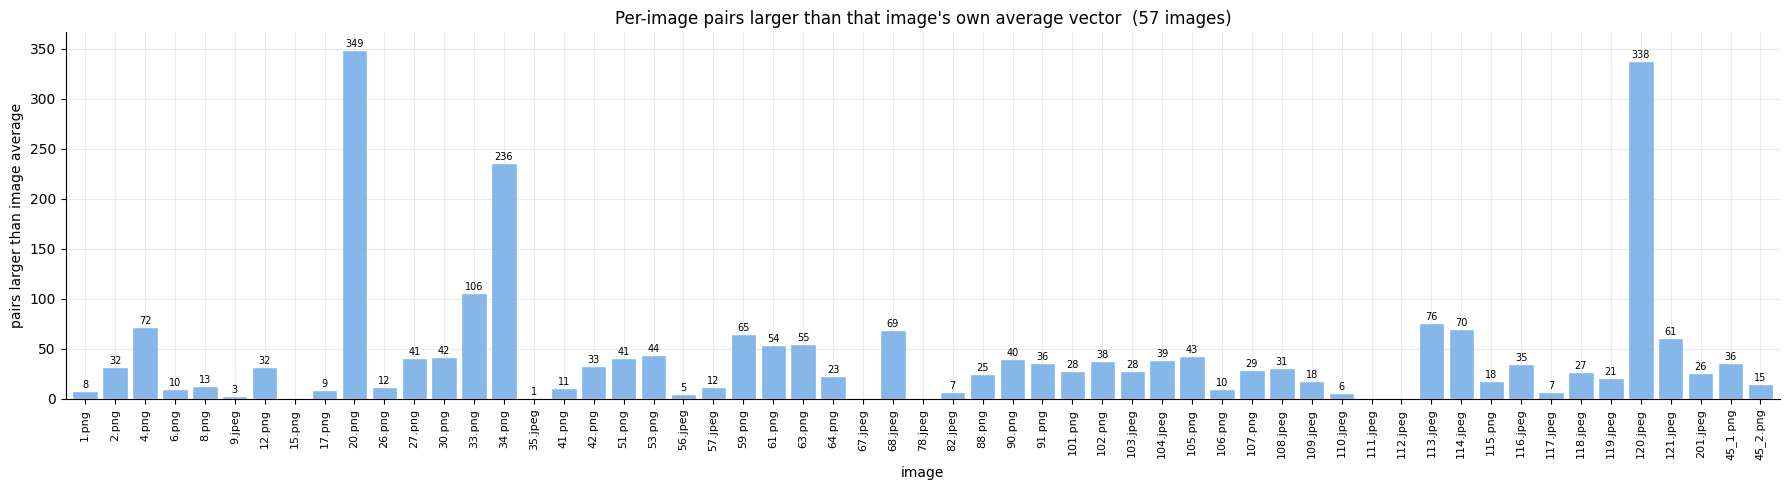

images: 57   degenerate (grey, 0 vectors): 15.png, 67.jpeg, 78.jpeg, 111.jpeg, 112.jpeg


In [24]:
# ── 57 bars in image order: per-image count of vectors larger than its own average ──
pi = disp_run.per_image.copy()
pi["larger"] = pd.to_numeric(pi["larger"], errors="coerce").fillna(0).astype(int)

# keep the natural numeric image order (1, 2, ... 201)
def _imgkey(s):
    stem = str(s).split(".")[0]
    return (int(stem) if stem.isdigit() else 10**9, str(s))
pi = pi.sort_values("image_id", key=lambda c: c.map(_imgkey)).reset_index(drop=True)

labels = pi["image_id"].tolist()
larger = pi["larger"].to_numpy()
is_deg = (pi["status"] != "ok").to_numpy()
colors = np.where(is_deg, "#E0E0E0", "#85B7EB")   # grey = degenerate (no vectors)

fig, ax = plt.subplots(figsize=(18, 5))
xs = np.arange(len(pi))
bars = ax.bar(xs, larger, color=colors, edgecolor="white", width=0.85)

for b, lg in zip(bars, larger):
    if lg > 0:
        ax.annotate(f"{lg}", (b.get_x()+b.get_width()/2, b.get_height()),
                    xytext=(0, 2), textcoords="offset points", ha="center", fontsize=7)

ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_ylabel("pairs larger than image average")
ax.set_xlabel("image")
ax.set_title(f"Per-image pairs larger than that image's own average vector  ({len(pi)} images)")
ax.margins(x=0.004)
fig.tight_layout()
fig.savefig(disp_run.out_dir / "larger_than_avg_per_image_bar.png", dpi=150)
plt.show()

print(f"images: {len(pi)}   degenerate (grey, 0 vectors): "
      f"{', '.join(pi.loc[is_deg, 'image_id'])}")

DATASET — gated pairs vs ground truth   (N=4605, real=714, 15.5%)
                      real    not-real    %real
  <= avg (below)       416       1703     19.6%
  >  avg (above)       298       2188     12.0%
  of all 714 real pairs: 416 are below (58.3%), 298 above (41.7%)


**Per image — % of below-avg vs above-avg pairs that are real**

,image_id,n_below,below_real,below_real_pct,n_above,above_real,above_real_pct
0,1.png,3,2,66.7,8,6,75.0
1,2.png,28,8,28.6,32,8,25.0
2,4.png,67,16,23.9,72,12,16.7
3,6.png,11,4,36.4,10,2,20.0
4,8.png,9,2,22.2,13,2,15.4
5,9.jpeg,5,3,60.0,3,2,66.7
6,12.png,32,11,34.4,32,4,12.5
7,17.png,10,4,40.0,9,0,0.0
8,20.png,252,29,11.5,349,12,3.4
9,26.png,11,0,0.0,12,2,16.7


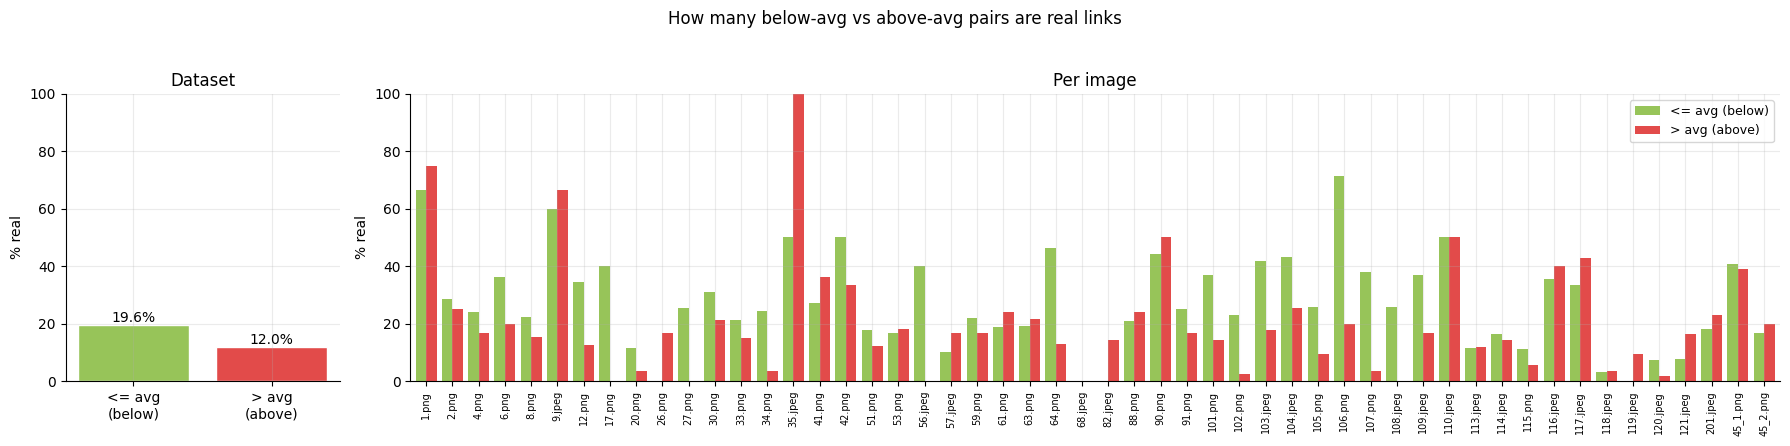

In [25]:
import re, math

# ── "real pair" oracle: candidate (nutrient, quantity) matches a GT row ──
def _norm_nut(s):
    s = str(s).lower().replace("ß", "ss").replace("ä", "a").replace("ö", "o").replace("ü", "u")
    return re.sub(r"[^a-z0-9]+", "", s)

def _qty_val(s):
    m = re.search(r"\d+\.?\d*", str(s).replace(",", "."))
    try:    return float(m.group(0)) if m else None
    except: return None

def _nut_match(cn, gn):
    if len(gn) < 3: return cn == gn
    return (gn in cn) or (cn in gn)

gt_rows = load_gt_from_csv(GT_CSV_PATH)
gt_by_img = defaultdict(list)
for r in gt_rows:
    gt_by_img[r["image_id"]].append((_norm_nut(r["nutrient"]), _qty_val(r["quantity"])))

def _is_real(img, nut_text, qty_text):
    cn, cq = _norm_nut(nut_text), _qty_val(qty_text)
    if cq is None: return 0
    for gn, gq in gt_by_img.get(img, []):
        if gq is not None and abs(cq - gq) < 1e-6 and _nut_match(cn, gn):
            return 1
    return 0

# ── flag every gated pair: above/below its image average, and real/not ──
pairs   = disp_run.pairs.copy()
avg_mag = disp_run.per_image.set_index("image_id")["avg_magnitude"].to_dict()
pairs["mag"]     = np.hypot(pairs["dx"].astype(float), pairs["dy"].astype(float))
pairs["avg_mag"] = pairs["image_id"].map(avg_mag)
pairs["above"]   = (pairs["mag"] > pairs["avg_mag"]).astype(int)   # 1 = longer than avg vector
pairs["is_real"] = [_is_real(i, n, q) for i, n, q in
                    zip(pairs["image_id"], pairs["nutrient"], pairs["quantity"])]

# ── per-image breakdown ──
def _imgkey(s):
    stem = str(s).split(".")[0]
    return (int(stem) if stem.isdigit() else 10**9, str(s))

rows = []
for img, g in pairs.groupby("image_id", sort=False):
    be, ab = g[g["above"] == 0], g[g["above"] == 1]
    rows.append({
        "image_id": img,
        "n_below": len(be), "below_real": int(be["is_real"].sum()),
        "below_real_pct": round(100 * be["is_real"].mean(), 1) if len(be) else np.nan,
        "n_above": len(ab), "above_real": int(ab["is_real"].sum()),
        "above_real_pct": round(100 * ab["is_real"].mean(), 1) if len(ab) else np.nan,
    })
per_img = pd.DataFrame(rows).sort_values("image_id", key=lambda c: c.map(_imgkey)).reset_index(drop=True)
per_img.to_csv(disp_run.out_dir / "real_pair_by_avg_split_per_image.csv", index=False)

# ── dataset 2x2 (below/above  ×  real/not) ──
a = int(pairs[(pairs.above == 0) & (pairs.is_real == 1)].shape[0])   # below & real
b = int(pairs[(pairs.above == 0) & (pairs.is_real == 0)].shape[0])   # below & not
c = int(pairs[(pairs.above == 1) & (pairs.is_real == 1)].shape[0])   # above & real
d = int(pairs[(pairs.above == 1) & (pairs.is_real == 0)].shape[0])   # above & not
R = a + c
print(f"DATASET — gated pairs vs ground truth   (N={len(pairs)}, real={R}, {100*R/len(pairs):.1f}%)")
print(f"                      real    not-real    %real")
print(f"  <= avg (below)   {a:>7} {b:>10}   {100*a/max(a+b,1):>6.1f}%")
print(f"  >  avg (above)   {c:>7} {d:>10}   {100*c/max(c+d,1):>6.1f}%")
print(f"  of all {R} real pairs: {a} are below ({100*a/max(R,1):.1f}%), {c} above ({100*c/max(R,1):.1f}%)")

display(Markdown("**Per image — % of below-avg vs above-avg pairs that are real**"))
display(per_img)

# ── visual: dataset headline + per-image two-series bars ──
fig, (axL, axR) = plt.subplots(1, 2, figsize=(18, 4.5), gridspec_kw={"width_ratios": [1, 5]})
axL.bar(["<= avg\n(below)", "> avg\n(above)"],
        [100*a/max(a+b,1), 100*c/max(c+d,1)],
        color=["#97C459", "#E24B4A"], edgecolor="white")
for i, v in enumerate([100*a/max(a+b,1), 100*c/max(c+d,1)]):
    axL.annotate(f"{v:.1f}%", (i, v), xytext=(0, 2), textcoords="offset points",
                 ha="center", fontsize=10)
axL.set_ylim(0, 100); axL.set_ylabel("% real"); axL.set_title("Dataset")

ok = per_img.dropna(subset=["below_real_pct", "above_real_pct"], how="all")
xs = np.arange(len(ok)); w = 0.4
axR.bar(xs - w/2, ok["below_real_pct"].fillna(0), w, color="#97C459", label="<= avg (below)")
axR.bar(xs + w/2, ok["above_real_pct"].fillna(0), w, color="#E24B4A", label="> avg (above)")
axR.set_xticks(xs); axR.set_xticklabels(ok["image_id"], rotation=90, fontsize=7)
axR.set_ylim(0, 100); axR.set_ylabel("% real"); axR.set_title("Per image")
axR.legend(fontsize=9); axR.margins(x=0.004)
fig.suptitle("How many below-avg vs above-avg pairs are real links")
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(disp_run.out_dir / "real_pair_by_avg_split.png", dpi=150)
plt.show()

DATASET — gated pairs vs GT   (N=4605 · 14 carry a unit)
                       PAIR (nut+val)            TRIPLET (nut+val+unit)
                    real / n     %real          triplet / n    %trip
  <= avg (below)     416 / 2119   19.6%             2 / 2119    0.1%
  >  avg (above)     298 / 2486   12.0%             2 / 2486    0.1%
  of 714 real pairs: 416 below (58.3%) · 298 above (41.7%)


**Per image — % of below-avg vs above-avg pairs that are real (pair match)**

,image_id,n_below,below_real,below_real_pct,below_triplet,n_above,above_real,above_real_pct,above_triplet
0,1.png,3,2,66.7,0,8,6,75.0,0
1,2.png,28,8,28.6,0,32,8,25.0,0
2,4.png,67,16,23.9,0,72,12,16.7,0
3,6.png,11,4,36.4,0,10,2,20.0,0
4,8.png,9,2,22.2,0,13,2,15.4,0
5,9.jpeg,5,3,60.0,0,3,2,66.7,0
6,12.png,32,11,34.4,0,32,4,12.5,0
7,17.png,10,4,40.0,0,9,0,0.0,0
8,20.png,252,29,11.5,0,349,12,3.4,0
9,26.png,11,0,0.0,0,12,2,16.7,0


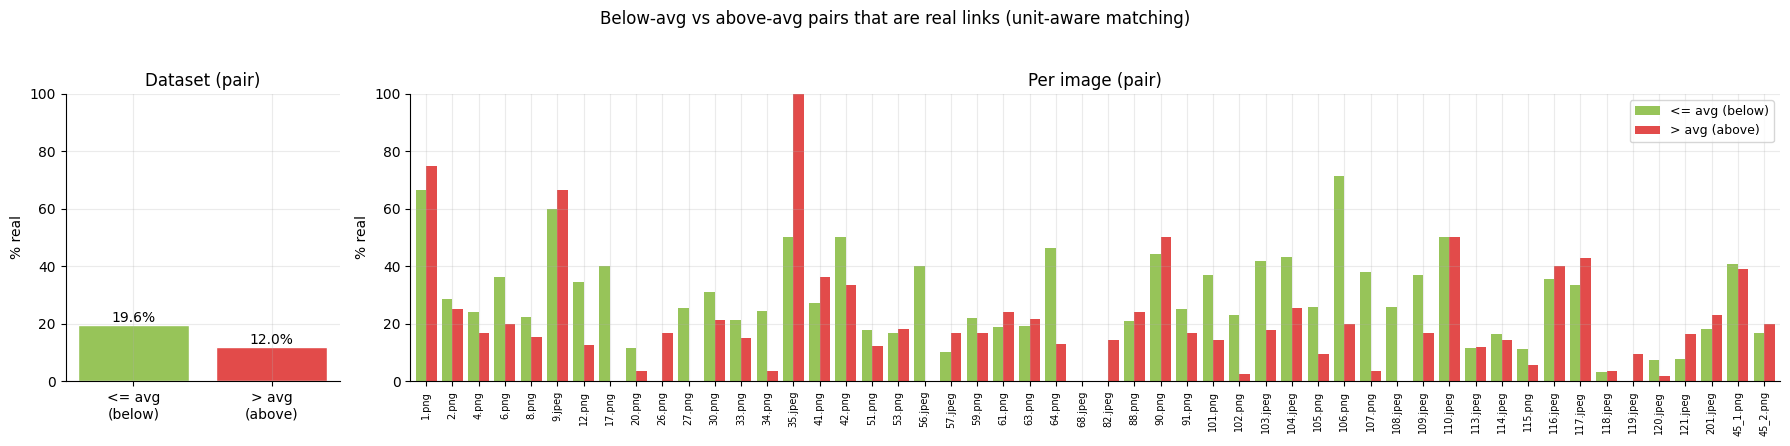

In [26]:
import re, math

# ── split a quantity token into (value, unit): "400mg"->(400,"mg"), "1,5 g"->(1.5,"g") ──
_UNIT_RE = re.compile(
    r'(kj/kcal|kcal/kj|kcal|kj|cal|mcg|µg|μg|ug|mg|kg|g|ml|dl|cl|l|iu|ie|kbe|cfu)\b',
    re.IGNORECASE)
def _unit_norm(u):
    u = (u or "").lower().replace("μg", "µg")
    return {"ug": "µg", "mcg": "µg", "ie": "iu"}.get(u, u)
def _qty_split(s):
    s = str(s).replace(",", ".")
    m = re.search(r"\d+\.?\d*", s)
    val = float(m.group(0)) if m else None
    um  = _UNIT_RE.search(s)
    return val, (_unit_norm(um.group(1)) if um else None)
def _norm_nut(s):
    s = str(s).lower().replace("ß","ss").replace("ä","a").replace("ö","o").replace("ü","u")
    return re.sub(r"[^a-z0-9]+", "", s)
def _nut_match(cn, gn):
    return (cn == gn) if len(gn) < 3 else ((gn in cn) or (cn in gn))

# ── GT indexed per image with value AND unit ──
gt_rows = load_gt_from_csv(GT_CSV_PATH)
gt_by_img = defaultdict(list)
for r in gt_rows:
    gv, gu_in = _qty_split(r["quantity"])
    gu = _unit_norm(r.get("unit", "")) or gu_in          # GT unit column, else parsed
    gt_by_img[r["image_id"]].append((_norm_nut(r["nutrient"]), gv, gu))

# match tiers: 2 = triplet (nut+val+unit), 1 = pair (nut+val), 0 = no match
def _match_level(img, nut_text, qty_text):
    cn, (cv, cu) = _norm_nut(nut_text), _qty_split(qty_text)
    if cv is None:
        return 0
    pair_hit = False
    for gn, gv, gu in gt_by_img.get(img, []):
        if gv is None or abs(cv - gv) >= 1e-6 or not _nut_match(cn, gn):
            continue
        pair_hit = True
        if cu is not None and gu and cu == gu:           # candidate has a unit -> require it
            return 2
    return 1 if pair_hit else 0

# ── flag gated pairs: above/below image average + match level ──
pairs   = disp_run.pairs.copy()
avg_mag = disp_run.per_image.set_index("image_id")["avg_magnitude"].to_dict()
pairs["mag"]     = np.hypot(pairs["dx"].astype(float), pairs["dy"].astype(float))
pairs["avg_mag"] = pairs["image_id"].map(avg_mag)
pairs["above"]   = (pairs["mag"] > pairs["avg_mag"]).astype(int)
lv = [_match_level(i, n, q) for i, n, q in zip(pairs["image_id"], pairs["nutrient"], pairs["quantity"])]
pairs["match_level"] = lv
pairs["is_real"]   = (pairs["match_level"] >= 1).astype(int)   # pair-or-better
pairs["is_triplet"]= (pairs["match_level"] == 2).astype(int)   # full triplet
pairs["has_unit"]  = [ _qty_split(q)[1] is not None for q in pairs["quantity"] ]

# ── per-image breakdown ──
def _imgkey(s):
    st = str(s).split(".")[0]; return (int(st) if st.isdigit() else 10**9, str(s))
rows = []
for img, g in pairs.groupby("image_id", sort=False):
    be, ab = g[g.above == 0], g[g.above == 1]
    rows.append({
        "image_id": img,
        "n_below": len(be), "below_real": int(be.is_real.sum()),
        "below_real_pct": round(100*be.is_real.mean(),1) if len(be) else np.nan,
        "below_triplet": int(be.is_triplet.sum()),
        "n_above": len(ab), "above_real": int(ab.is_real.sum()),
        "above_real_pct": round(100*ab.is_real.mean(),1) if len(ab) else np.nan,
        "above_triplet": int(ab.is_triplet.sum()),
    })
per_img = pd.DataFrame(rows).sort_values("image_id", key=lambda c: c.map(_imgkey)).reset_index(drop=True)
per_img.to_csv(disp_run.out_dir / "real_pair_by_avg_split_per_image.csv", index=False)

# ── dataset summary: pair-level and triplet-level, below vs above ──
def _split(col):
    be, ab = pairs[pairs.above == 0], pairs[pairs.above == 1]
    return (int(be[col].sum()), len(be), int(ab[col].sum()), len(ab))
br, bn, ar, an = _split("is_real")
bt, _,  at, _  = _split("is_triplet")
n_unit = int(pairs.has_unit.sum())
print(f"DATASET — gated pairs vs GT   (N={len(pairs)} · {n_unit} carry a unit)")
print(f"                       PAIR (nut+val)            TRIPLET (nut+val+unit)")
print(f"                    real / n     %real          triplet / n    %trip")
print(f"  <= avg (below)  {br:>6} /{bn:>5}  {100*br/max(bn,1):>5.1f}%        "
      f"{bt:>6} /{bn:>5}  {100*bt/max(bn,1):>5.1f}%")
print(f"  >  avg (above)  {ar:>6} /{an:>5}  {100*ar/max(an,1):>5.1f}%        "
      f"{at:>6} /{an:>5}  {100*at/max(an,1):>5.1f}%")
R = br + ar
print(f"  of {R} real pairs: {br} below ({100*br/max(R,1):.1f}%) · {ar} above ({100*ar/max(R,1):.1f}%)")

display(Markdown("**Per image — % of below-avg vs above-avg pairs that are real (pair match)**"))
display(per_img)

# ── visual: dataset headline + per-image two-series bars (pair-level) ──
fig, (axL, axR) = plt.subplots(1, 2, figsize=(18, 4.5), gridspec_kw={"width_ratios":[1,5]})
axL.bar(["<= avg\n(below)", "> avg\n(above)"], [100*br/max(bn,1), 100*ar/max(an,1)],
        color=["#97C459", "#E24B4A"], edgecolor="white")
for i, v in enumerate([100*br/max(bn,1), 100*ar/max(an,1)]):
    axL.annotate(f"{v:.1f}%", (i, v), xytext=(0,2), textcoords="offset points", ha="center", fontsize=10)
axL.set_ylim(0, 100); axL.set_ylabel("% real"); axL.set_title("Dataset (pair)")
ok = per_img.dropna(subset=["below_real_pct","above_real_pct"], how="all")
xs = np.arange(len(ok)); w = 0.4
axR.bar(xs - w/2, ok["below_real_pct"].fillna(0), w, color="#97C459", label="<= avg (below)")
axR.bar(xs + w/2, ok["above_real_pct"].fillna(0), w, color="#E24B4A", label="> avg (above)")
axR.set_xticks(xs); axR.set_xticklabels(ok["image_id"], rotation=90, fontsize=7)
axR.set_ylim(0, 100); axR.set_ylabel("% real"); axR.set_title("Per image (pair)")
axR.legend(fontsize=9); axR.margins(x=0.004)
fig.suptitle("Below-avg vs above-avg pairs that are real links (unit-aware matching)")
fig.tight_layout(rect=[0,0,1,0.95])
fig.savefig(disp_run.out_dir / "real_pair_by_avg_split.png", dpi=150)
plt.show()

GROUND-TRUTH RECALL — is there a BELOW-average candidate for each gold pair?  (N=866 numeric GT pairs)
  PAIR  (nutrient + value)
    below avg  (RECALL)      :  366    42.3%
    above avg                :  255    29.4%
    either bucket (ceiling)  :  540    62.4%   <- limited by OCR detection
    of recovered, below share:  67.8%
  TRIPLET (nutrient + value + unit)
    below avg  (recall)      :    2     0.2%
    above avg                :    2     0.2%
  recall loss split: filter (true link above avg) = 174   detection (never found) = 326
  GT pairs in degenerate images (unreachable): 50


**Per-image recall — gold pairs recovered below the image average**

,image_id,gt_numeric,below_hit,above_hit,any_hit,recall_below_pct
0,1.png,5,3,5,5,60.0
1,2.png,16,11,9,14,68.8
2,4.png,8,5,4,5,62.5
3,6.png,6,4,2,6,66.7
4,8.png,18,2,2,4,11.1
5,9.jpeg,4,2,1,3,50.0
6,12.png,16,8,4,10,50.0
7,15.png,42,0,0,0,0.0
8,17.png,4,4,0,4,100.0
9,20.png,48,20,10,27,41.7


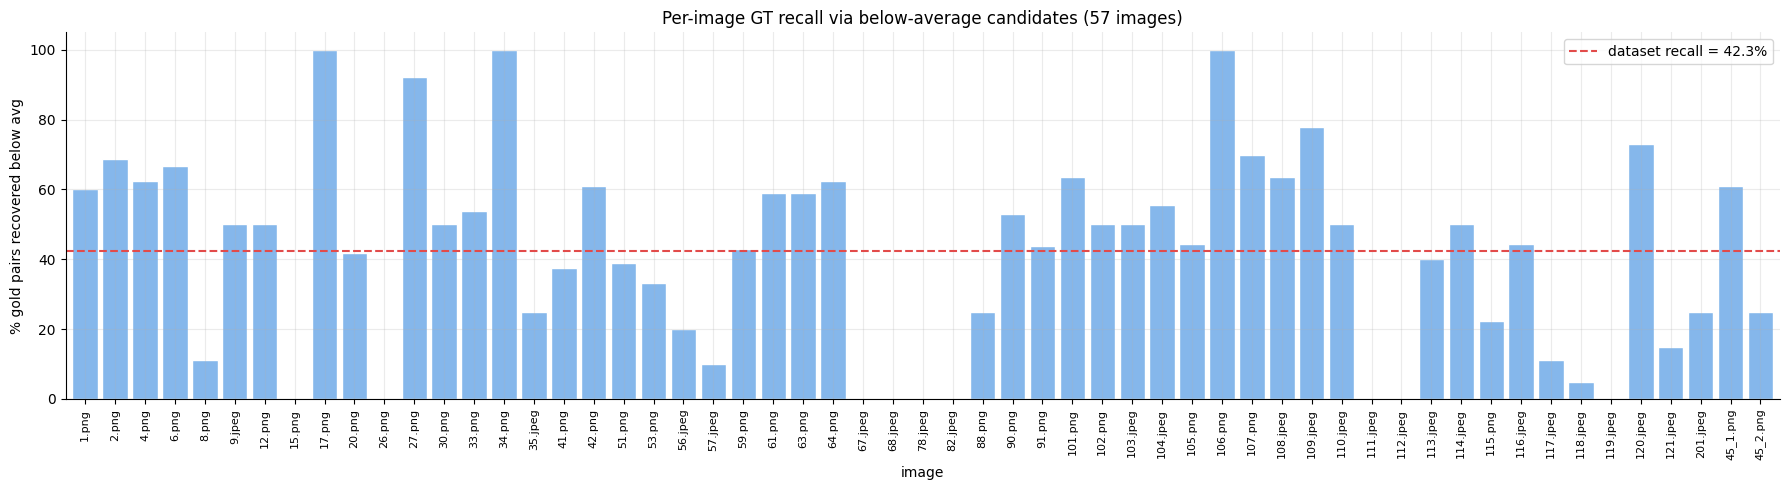

In [27]:
import re

# ── unit-aware GT oracle (self-contained) ──
_UNIT_RE = re.compile(r'(kj/kcal|kcal/kj|kcal|kj|cal|mcg|µg|μg|ug|mg|kg|g|ml|dl|cl|l|iu|ie|kbe|cfu)\b', re.I)
def _unit_norm(u):
    u = (u or "").lower().replace("μg", "µg")
    return {"ug": "µg", "mcg": "µg", "ie": "iu"}.get(u, u)
def _qty_split(s):
    s = str(s).replace(",", "."); m = re.search(r"\d+\.?\d*", s)
    um = _UNIT_RE.search(s)
    return (float(m.group(0)) if m else None), (_unit_norm(um.group(1)) if um else None)
def _norm_nut(s):
    s = str(s).lower().replace("ß","ss").replace("ä","a").replace("ö","o").replace("ü","u")
    return re.sub(r"[^a-z0-9]+", "", s)
def _nut_match(cn, gn):
    return (cn == gn) if len(gn) < 3 else ((gn in cn) or (cn in gn))

gt_rows = load_gt_from_csv(GT_CSV_PATH)
gt_by_img = defaultdict(list)
for r in gt_rows:
    gv, gu_in = _qty_split(r["quantity"])
    gt_by_img[r["image_id"]].append((_norm_nut(r["nutrient"]), gv, _unit_norm(r.get("unit","")) or gu_in))

# ── split candidate pairs by the image's average vector ──
pairs = disp_run.pairs.copy()
avg_mag = disp_run.per_image.set_index("image_id")["avg_magnitude"].to_dict()
pairs["mag"]   = np.hypot(pairs["dx"].astype(float), pairs["dy"].astype(float))
pairs["below"] = (pairs["mag"] <= pairs["image_id"].map(avg_mag)).astype(int)   # 1 = <= avg
cand = {"below": defaultdict(list), "above": defaultdict(list)}
for _, p in pairs.iterrows():
    cand["below" if p["below"] else "above"][p["image_id"]].append(
        (_norm_nut(p["nutrient"]), *_qty_split(p["quantity"])))

def _row_hit(cands, gn, gv, gu):
    pair = trip = False
    for cn, cv, cu in cands:
        if cv is None or gv is None: continue
        if abs(cv - gv) < 1e-6 and _nut_match(cn, gn):
            pair = True
            if cu and gu and cu == gu: trip = True
    return pair, trip

# ── recall over GT rows ──
deg_ids = set(disp_run.per_image[disp_run.per_image["status"] != "ok"]["image_id"])
rows = []
for img, gts in gt_by_img.items():
    bc, ac = cand["below"].get(img, []), cand["above"].get(img, [])
    n_val = bp = ap = anyp = bt = at = 0
    for gn, gv, gu in gts:
        if gv is None: continue
        n_val += 1
        b_p, b_t = _row_hit(bc, gn, gv, gu); a_p, a_t = _row_hit(ac, gn, gv, gu)
        bp += b_p; ap += a_p; anyp += (b_p or a_p); bt += b_t; at += a_t
    rows.append({"image_id": img, "degenerate": img in deg_ids, "gt_numeric": n_val,
                 "below_hit": bp, "above_hit": ap, "any_hit": anyp,
                 "recall_below_pct": round(100*bp/n_val,1) if n_val else np.nan,
                 "below_trip": bt, "above_trip": at})

def _imgkey(s):
    st = str(s).split(".")[0]; return (int(st) if st.isdigit() else 10**9, str(s))
rec_df = pd.DataFrame(rows).sort_values("image_id", key=lambda c: c.map(_imgkey)).reset_index(drop=True)
rec_df.to_csv(disp_run.out_dir / "gt_recall_below_avg.csv", index=False)

# ── dataset totals ──
N  = int(rec_df["gt_numeric"].sum())
Bp = int(rec_df["below_hit"].sum()); Ap = int(rec_df["above_hit"].sum()); Yp = int(rec_df["any_hit"].sum())
Bt = int(rec_df["below_trip"].sum()); At = int(rec_df["above_trip"].sum())
deg_gt = int(rec_df[rec_df["degenerate"]]["gt_numeric"].sum())
print(f"GROUND-TRUTH RECALL — is there a BELOW-average candidate for each gold pair?  (N={N} numeric GT pairs)")
print(f"  PAIR  (nutrient + value)")
print(f"    below avg  (RECALL)      : {Bp:>4}   {100*Bp/max(N,1):5.1f}%")
print(f"    above avg                : {Ap:>4}   {100*Ap/max(N,1):5.1f}%")
print(f"    either bucket (ceiling)  : {Yp:>4}   {100*Yp/max(N,1):5.1f}%   <- limited by OCR detection")
print(f"    of recovered, below share: {100*Bp/max(Yp,1):5.1f}%")
print(f"  TRIPLET (nutrient + value + unit)")
print(f"    below avg  (recall)      : {Bt:>4}   {100*Bt/max(N,1):5.1f}%")
print(f"    above avg                : {At:>4}   {100*At/max(N,1):5.1f}%")
print(f"  recall loss split: filter (true link above avg) = {Yp-Bp}   detection (never found) = {N-Yp}")
print(f"  GT pairs in degenerate images (unreachable): {deg_gt}")

display(Markdown("**Per-image recall — gold pairs recovered below the image average**"))
display(rec_df[["image_id","gt_numeric","below_hit","above_hit","any_hit","recall_below_pct"]])

# ── per-image recall bar ──
colors = np.where(rec_df["degenerate"].to_numpy(), "#E0E0E0", "#85B7EB")
fig, ax = plt.subplots(figsize=(18,5)); xs = np.arange(len(rec_df))
ax.bar(xs, rec_df["recall_below_pct"].fillna(0), color=colors, edgecolor="white", width=0.85)
ax.axhline(100*Bp/max(N,1), color="#E24B4A", ls="--", lw=1.5, label=f"dataset recall = {100*Bp/max(N,1):.1f}%")
ax.set_xticks(xs); ax.set_xticklabels(rec_df["image_id"], rotation=90, fontsize=8)
ax.set_ylim(0,105); ax.set_ylabel("% gold pairs recovered below avg"); ax.set_xlabel("image")
ax.set_title(f"Per-image GT recall via below-average candidates ({len(rec_df)} images)")
ax.legend(); ax.margins(x=0.004); fig.tight_layout()
fig.savefig(disp_run.out_dir / "gt_recall_below_avg_bar.png", dpi=150); plt.show()

GT PAIR OUTCOMES — is 'above average' a missing-value signal?   (N=866)
  A  recovered below avg          :  366 (42.3%)  kept, correct
  B  recovered ONLY above avg     :  174 (20.1%)  detected, just far
  C  detected but never linked    :  128 (14.8%)  number on page, link failed
  D  value NOT detected = OCR DROP :  198 (22.9%)  true missing value
  -----------------------------------------------
  sanity: above-average matches that are detected = 255/255 (100.0%, expect ~100%)

  -> above-average pairs are detected, NOT drops.
  -> true OCR drops = D = 198; they have no displacement, so the above/below test cannot see them.
  -> the 326 'neither bucket' = C (128) detected-but-mislinked + D (198) true drops.


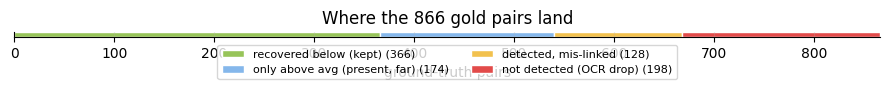

In [28]:
import re

_UNIT_RE = re.compile(r'(kj/kcal|kcal/kj|kcal|kj|cal|mcg|µg|μg|ug|mg|kg|g|ml|dl|cl|l|iu|ie|kbe|cfu)\b', re.I)
def _unit_norm(u):
    u=(u or "").lower().replace("μg","µg"); return {"ug":"µg","mcg":"µg","ie":"iu"}.get(u,u)
def _qty_split(s):
    s=str(s).replace(",","."); m=re.search(r"\d+\.?\d*",s); um=_UNIT_RE.search(s)
    return (float(m.group(0)) if m else None),(_unit_norm(um.group(1)) if um else None)
def _norm_nut(s):
    s=str(s).lower().replace("ß","ss").replace("ä","a").replace("ö","o").replace("ü","u")
    return re.sub(r"[^a-z0-9]+","",s)
def _nut_match(cn,gn): return (cn==gn) if len(gn)<3 else ((gn in cn) or (cn in gn))
def _val_in(v, vals, tol=1e-3): return any(abs(v-d)<tol for d in vals)

# (1) re-run front-end -> ALL detected QUANTITY values per image (same OCR+classifier as disp_run)
ocr_fn  = build_ocr_engine(displacement_config["ocr_engine"])
corr_fn = build_corrector(displacement_config["ocr_engine"])
clf     = build_classifier(displacement_config["classifier_key"])
detected_qty = {}
imgs = list_images(RAW_DIR, limit=ablation_config["debug"]["limit_images"])
for k, img in enumerate(imgs, 1):
    iid = img.stem + img.suffix.lower()
    toks = _ensure_cx_cy(ocr_fn(str(img)))
    corr, _ = corr_fn(toks); corr = _ensure_cx_cy(corr)
    lab = clf.classify_all(corr)
    vals = [round(_qty_split(t.get("norm") or t.get("token") or "")[0], 4)
            for t in lab if t.get("label") == "QUANTITY"
            and _qty_split(t.get("norm") or t.get("token") or "")[0] is not None]
    detected_qty[iid] = vals
    if k % 10 == 0 or k == len(imgs):
        logger.info("[detect] %d/%d scanned for QUANTITY tokens", k, len(imgs))

# (2) GT pairs
gt_rows = load_gt_from_csv(GT_CSV_PATH)
gt_by_img = defaultdict(list)
for r in gt_rows:
    gv, _gu = _qty_split(r["quantity"]); gt_by_img[r["image_id"]].append((_norm_nut(r["nutrient"]), gv))

# (3) below / above candidate buckets from disp_run.pairs
pairs = disp_run.pairs.copy()
avg_mag = disp_run.per_image.set_index("image_id")["avg_magnitude"].to_dict()
pairs["mag"]   = np.hypot(pairs["dx"].astype(float), pairs["dy"].astype(float))
pairs["below"] = (pairs["mag"] <= pairs["image_id"].map(avg_mag)).astype(int)
bucket = {"below": defaultdict(list), "above": defaultdict(list)}
for _, p in pairs.iterrows():
    bucket["below" if p["below"] else "above"][p["image_id"]].append(
        (_norm_nut(p["nutrient"]), _qty_split(p["quantity"])[0]))
def _matched(cands, gn, gv):
    return any(cv is not None and abs(cv-gv)<1e-6 and _nut_match(cn,gn) for cn,cv in cands)

# (4) classify every gold pair into A/B/C/D
rows = []
for img, gts in gt_by_img.items():
    dv = detected_qty.get(img, []); bc = bucket["below"].get(img, []); ac = bucket["above"].get(img, [])
    for gn, gv in gts:
        if gv is None: continue
        det, below, above = _val_in(gv, dv), _matched(bc, gn, gv), _matched(ac, gn, gv)
        cat = ("A_recovered_below" if below else "B_only_above" if above
               else "C_detected_unmatched" if det else "D_not_detected_DROP")
        rows.append({"image_id": img, "nutrient": gn, "gold_value": gv,
                     "detected": int(det), "below": int(below), "above": int(above), "category": cat})
gtc = pd.DataFrame(rows); gtc.to_csv(disp_run.out_dir / "gt_pair_outcome_categories.csv", index=False)

# (5) report
N = len(gtc); cc = gtc["category"].value_counts().to_dict()
A=cc.get("A_recovered_below",0); B=cc.get("B_only_above",0)
C=cc.get("C_detected_unmatched",0); D=cc.get("D_not_detected_DROP",0)
at=int(gtc["above"].sum()); ad=int(gtc[gtc["above"]==1]["detected"].sum())
print(f"GT PAIR OUTCOMES — is 'above average' a missing-value signal?   (N={N})")
print(f"  A  recovered below avg          : {A:>4} ({100*A/N:4.1f}%)  kept, correct")
print(f"  B  recovered ONLY above avg     : {B:>4} ({100*B/N:4.1f}%)  detected, just far")
print(f"  C  detected but never linked    : {C:>4} ({100*C/N:4.1f}%)  number on page, link failed")
print(f"  D  value NOT detected = OCR DROP : {D:>4} ({100*D/N:4.1f}%)  true missing value")
print(f"  -----------------------------------------------")
print(f"  sanity: above-average matches that are detected = {ad}/{at} "
      f"({100*ad/max(at,1):.1f}%, expect ~100%)")
print(f"\n  -> above-average pairs are detected, NOT drops.")
print(f"  -> true OCR drops = D = {D}; they have no displacement, so the above/below test cannot see them.")
print(f"  -> the 326 'neither bucket' = C ({C}) detected-but-mislinked + D ({D}) true drops.")

fig, ax = plt.subplots(figsize=(9,1.8)); left=0
for lab,val,col in [("recovered below (kept)",A,"#97C459"),("only above avg (present, far)",B,"#85B7EB"),
                    ("detected, mis-linked",C,"#F2C14E"),("not detected (OCR drop)",D,"#E24B4A")]:
    ax.barh(0,val,left=left,color=col,edgecolor="white",label=f"{lab} ({val})"); left+=val
ax.set_xlim(0,N); ax.set_yticks([]); ax.set_xlabel("ground-truth pairs")
ax.set_title(f"Where the {N} gold pairs land")
ax.legend(ncol=2, fontsize=8, loc="upper center", bbox_to_anchor=(0.5,-0.6))
fig.tight_layout(); fig.savefig(disp_run.out_dir / "gt_pair_outcome_bar.png", dpi=150); plt.show()

In [29]:
# Within each image: did a nutrient land above-average BECAUSE its own gold qty is missing
# while it mis-grabbed a DIFFERENT detected value? (neighbour-steal signal)
import re
def _norm_nut(s):
    s=str(s).lower().replace("ß","ss").replace("ä","a").replace("ö","o").replace("ü","u")
    return re.sub(r"[^a-z0-9]+","",s)
def _val(s):
    m=re.search(r"\d+\.?\d*",str(s).replace(",",".")); return float(m.group(0)) if m else None
def _nm(a,b): return (a==b) if len(b)<3 else ((b in a) or (a in b))

gt_rows = load_gt_from_csv(GT_CSV_PATH)
gt_nut_qty = defaultdict(dict)                       # img -> {norm_nut: gold_value}
for r in gt_rows:
    v=_val(r["quantity"])
    if v is not None: gt_nut_qty[r["image_id"]][_norm_nut(r["nutrient"])]=v

p = disp_run.pairs.copy()
am = disp_run.per_image.set_index("image_id")["avg_magnitude"].to_dict()
p["mag"]=np.hypot(p.dx.astype(float),p.dy.astype(float)); p["above"]=(p["mag"]>p.image_id.map(am)).astype(int)
p["gval"]=p["quantity"].map(_val); p["nnut"]=p["nutrient"].map(_norm_nut)

# best (shortest) candidate each nutrient actually took, per image
steal=0; total_above_nut=0; rows=[]
for img,g in p.groupby("image_id"):
    det=set(round(v,3) for v in g["gval"].dropna())             # values detected on this image
    for nut,gn in g.groupby("nnut"):
        gold=gt_nut_qty.get(img,{}).get(nut)
        if gold is None: continue
        best=gn.loc[gn["mag"].idxmin()]                          # the link this nutrient took
        if best["above"]==1:                                     # nutrient's chosen link is above avg
            total_above_nut+=1
            own_missing = round(gold,3) not in det               # its OWN gold value absent
            grabbed_other = best["gval"] is not None and abs(best["gval"]-gold)>=1e-6
            if own_missing and grabbed_other:
                steal+=1
                rows.append({"image_id":img,"nutrient":nut,"gold":gold,
                             "grabbed":best["gval"],"mag":round(best["mag"],1)})
print(f"Nutrients whose chosen link is ABOVE average      : {total_above_nut}")
print(f"  ...because their OWN gold qty is NOT detected and")
print(f"     they grabbed a different value (neighbour steal): {steal} "
      f"({100*steal/max(total_above_nut,1):.1f}%)")
display(pd.DataFrame(rows).head(20))

Nutrients whose chosen link is ABOVE average      : 36
  ...because their OWN gold qty is NOT detected and
     they grabbed a different value (neighbour steal): 8 (22.2%)


,image_id,nutrient,gold,grabbed,mag
0,101.png,vitaminb1,0.44,36.00,1166.3
1,117.jpeg,protein,11.00,0.04,694.0
2,35.jpeg,vitaminc,100.80,2.10,209.2
3,41.png,energy,144.00,0.00,1792.6
4,45_2.png,energy,374.00,0.00,1213.5
5,53.png,energy,218.00,1541.00,1882.2
6,82.jpeg,fat,0.00,3.00,213.7
7,90.png,magnesium,56.00,0.10,1777.9


In [30]:
# Do the 174 (B) live on images that ALSO have undetected gold values (D drops)?
# gtc = the A/B/C/D table from the earlier cell (one row per gold pair, with 'category')

# per-image drop count (category D = value never detected)
drops_per_img = (gtc[gtc.category == "D_not_detected_DROP"]
                 .groupby("image_id").size())                 # img -> # OCR drops
b_per_img     = (gtc[gtc.category == "B_only_above"]
                 .groupby("image_id").size())                 # img -> # of the 174 on that image

imgs_with_B = set(b_per_img.index)
B_total     = int(b_per_img.sum())                            # == 174

# how many of the 174 sit on an image that has >=1 drop
B_on_dropimg = int(sum(n for img, n in b_per_img.items() if drops_per_img.get(img, 0) > 0))
imgs_B_and_drops = sorted(img for img in imgs_with_B if drops_per_img.get(img, 0) > 0)

print(f"The 174 above-average correct links (category B):")
print(f"  total                                   : {B_total}")
print(f"  sitting on an image that ALSO has >=1 OCR drop (D): {B_on_dropimg} "
      f"({100*B_on_dropimg/max(B_total,1):.1f}%)")
print(f"  sitting on a fully-clean image (no D)            : {B_total-B_on_dropimg} "
      f"({100*(B_total-B_on_dropimg)/max(B_total,1):.1f}%)")
print(f"  images carrying B links                 : {len(imgs_with_B)}")
print(f"  ...of which also have >=1 drop          : {len(imgs_B_and_drops)}")

# per-image side by side: B count vs drop count, and B's share of that image's gold
gt_per_img = gtc.groupby("image_id").size()
tbl = pd.DataFrame({
    "B_above_correct": b_per_img,
    "D_ocr_drops":     drops_per_img,
    "gt_pairs":        gt_per_img,
}).fillna(0).astype(int)
tbl = tbl[tbl["B_above_correct"] > 0].copy()
tbl["drops_per_gt_%"] = (100*tbl["D_ocr_drops"]/tbl["gt_pairs"]).round(1)
tbl = tbl.sort_values("D_ocr_drops", ascending=False)
display(Markdown("**Images carrying above-average correct links (B), with their OCR-drop load (D)**"))
display(tbl)

# the actual question, quantified as correlation across images
import numpy as np
common = tbl.index
r = np.corrcoef(tbl["B_above_correct"], tbl["D_ocr_drops"])[0,1] if len(tbl) > 1 else float("nan")
print(f"\nAcross the {len(tbl)} B-carrying images, corr(B count, drop count) = {r:.2f}")
print("  positive -> images with more above-average correct links also tend to have more OCR drops")

The 174 above-average correct links (category B):
  total                                   : 174
  sitting on an image that ALSO has >=1 OCR drop (D): 131 (75.3%)
  sitting on a fully-clean image (no D)            : 43 (24.7%)
  images carrying B links                 : 43
  ...of which also have >=1 drop          : 31


**Images carrying above-average correct links (B), with their OCR-drop load (D)**

,B_above_correct,D_ocr_drops,gt_pairs,drops_per_gt_%
image_id,,,,
8.png,2,14,18,77.8
82.jpeg,1,11,12,91.7
20.png,7,7,48,14.6
59.png,8,7,28,25.0
103.jpeg,4,5,18,27.8
88.png,5,5,16,31.2
117.jpeg,3,5,9,55.6
45_1.png,3,4,18,22.2
121.jpeg,10,4,20,20.0



Across the 43 B-carrying images, corr(B count, drop count) = -0.02
  positive -> images with more above-average correct links also tend to have more OCR drops


In [31]:
# Is the AVERAGE the fragile part? Re-classify B links under a drop-robust reference.
p = disp_run.pairs.copy()
p["mag"] = np.hypot(p.dx.astype(float), p.dy.astype(float))

# current: above = mag > image-mean-vector magnitude  (what produced the 174)
am_mean = disp_run.per_image.set_index("image_id")["avg_magnitude"].to_dict()
p["above_mean"] = (p["mag"] > p.image_id.map(am_mean)).astype(int)

# robust A: per-image MEDIAN magnitude (one big drop barely moves a median)
med_mag = p.groupby("image_id")["mag"].transform("median")
p["above_med"] = (p["mag"] > med_mag).astype(int)

# robust B: per-COLUMN median magnitude (drops in one column don't shift the others)
p["col_med"] = p.groupby(["image_id","column"])["mag"].transform("median")
p["above_colmed"] = (p["mag"] > p["col_med"]).astype(int)

# robust C: trim the top 10% longest pairs before averaging (mimics removing far-pair drops)
def _trim_mean_mag(g):
    v = np.sort(g.values); v = v[: max(1, int(len(v)*0.9))]; return v.mean()
tm = p.groupby("image_id")["mag"].transform(lambda s: _trim_mean_mag(s))
p["above_trim"] = (p["mag"] > tm).astype(int)

for col,name in [("above_mean","mean (current)"),("above_med","image median"),
                 ("above_colmed","column median"),("above_trim","trimmed mean (-10% longest)")]:
    print(f"  pairs above {name:<28}: {int(p[col].sum())}")

print("\n  -> if 'above' count is stable across these, the average is NOT fragile to drops.")
print("  -> if it drops sharply under median/column-median, the mean WAS the sensitive part (your point).")

  pairs above mean (current)              : 2486
  pairs above image median                : 2293
  pairs above column median               : 2288
  pairs above trimmed mean (-10% longest) : 2567

  -> if 'above' count is stable across these, the average is NOT fragile to drops.
  -> if it drops sharply under median/column-median, the mean WAS the sensitive part (your point).


In [32]:
import re
def _val(s):
    m = re.search(r"\d+\.?\d*", str(s).replace(",", ".")); return float(m.group(0)) if m else None
def _norm_nut(s):
    s = str(s).lower().replace("ß","ss").replace("ä","a").replace("ö","o").replace("ü","u")
    return re.sub(r"[^a-z0-9]+", "", s)

# (1) detected QUANTITY values per image (the key difference: label == QUANTITY only)
ocr_fn  = build_ocr_engine(displacement_config["ocr_engine"])
corr_fn = build_corrector(displacement_config["ocr_engine"])
clf     = build_classifier(displacement_config["classifier_key"])
det_qty = {}
for k, img in enumerate(list_images(RAW_DIR, limit=ablation_config["debug"]["limit_images"]), 1):
    iid = img.stem + img.suffix.lower()
    toks = _ensure_cx_cy(ocr_fn(str(img))); corr, _ = corr_fn(toks); corr = _ensure_cx_cy(corr)
    lab = clf.classify_all(corr)
    det_qty[iid] = set(round(_val(t.get("norm") or t.get("token") or ""), 3)
                       for t in lab if t.get("label") == "QUANTITY"
                       and _val(t.get("norm") or t.get("token") or "") is not None)

# (2) per image: which gold QUANTITY values were never detected as a QUANTITY token
gt_rows = load_gt_from_csv(GT_CSV_PATH)
gt_by_img = defaultdict(list)
for r in gt_rows:
    v = _val(r["quantity"])
    if v is not None: gt_by_img[r["image_id"]].append((_norm_nut(r["nutrient"]), round(v, 3)))

qdrop_by_img, qdrop_vals = {}, {}
for img, gts in gt_by_img.items():
    dv = det_qty.get(img, set())
    missed = [(n, v) for n, v in gts if v not in dv]      # gold quantity absent from detected QTY
    qdrop_by_img[img] = len(missed)
    qdrop_vals[img]   = ", ".join(f"{n}={v:g}" for n, v in missed)[:90] or "—"

# (3) annotate the 174 (category B) with QUANTITY-only drops on their image
B = gtc[gtc.category == "B_only_above"].copy()
B["img_qty_drops"]   = B["image_id"].map(qdrop_by_img).fillna(0).astype(int)
B["img_qty_dropped"] = B["image_id"].map(qdrop_vals).fillna("—")

nB = len(B); B_on_qdrop = int((B["img_qty_drops"] > 0).sum())
print(f"Of the {nB} correct-but-above-average links (B), QUANTITY drops only:")
print(f"  on an image with >=1 undetected QUANTITY   : {B_on_qdrop} ({100*B_on_qdrop/nB:.1f}%)")
print(f"  on an image with NO quantity drop          : {nB-B_on_qdrop} ({100*(nB-B_on_qdrop)/nB:.1f}%)")
print(f"  mean / median / max qty-drops on a B image : "
      f"{B['img_qty_drops'].mean():.1f} / {int(B['img_qty_drops'].median())} / {B['img_qty_drops'].max()}")

roll = (B.groupby("image_id")
          .agg(B_links=("nutrient","size"), qty_drops=("img_qty_drops","first"),
               dropped_quantities=("img_qty_dropped","first"))
          .reset_index().sort_values("qty_drops", ascending=False))
display(Markdown("**Images carrying B links: undetected QUANTITY values on each**"))
display(roll)
B.to_csv(disp_run.out_dir / "B_links_with_quantity_drops.csv", index=False)

Of the 174 correct-but-above-average links (B), QUANTITY drops only:
  on an image with >=1 undetected QUANTITY   : 131 (75.3%)
  on an image with NO quantity drop          : 43 (24.7%)
  mean / median / max qty-drops on a B image : 2.4 / 2 / 14


**Images carrying B links: undetected QUANTITY values on each**

,image_id,B_links,qty_drops,dropped_quantities
37,8.png,2,14,"energy=892, energy=213, saturatedfats=3.4, carbohydrate=41, sugars=21, fibre..."
38,82.jpeg,1,11,"energy=0, energy=0, protein=0, carbohydrate=0, fat=0, creatinemonohydrate=10..."
19,20.png,7,7,"energy=1474, energy=346, vitamine=67, vitamina=2220, energy=223, energy=52, ..."
32,59.png,8,7,"energy=330, fructose=63.7, vitamine=50, vitamina=1667, energy=66, vitamine=1..."
3,103.jpeg,4,5,"salt=0, energy=166, saturatedfats=0, protein=0.9, salt=0"
39,88.png,5,5,"energy=234, energy=55, fat=0.7, energy=772, energy=181"
13,117.jpeg,3,5,"saturatedfats=1.5, carbohydrate=16.7, sugars=13.5, fibre=4, protein=11"
27,45_1.png,3,4,"carbohydrate=44, sugars=18, carbohydrate=94, sugars=38"
17,121.jpeg,10,4,"energy=1.401, energy=336, sugars=4.9, fibre=7.9"
25,41.png,1,4,"energy=612, energy=144, carbohydrate=36, sugars=4.5"


In [33]:
import re
def _norm_nut(s):
    s = str(s).lower().replace("ß","ss").replace("ä","a").replace("ö","o").replace("ü","u")
    return re.sub(r"[^a-z0-9]+", "", s)
def _nut_seen(gn, seen):
    return any((gn == s) or (len(gn) >= 3 and (gn in s or s in gn)) for s in seen)

# detected NUTRIENT names per image (same OCR+classifier pass as det_qty)
det_nut = {}
for img in list_images(RAW_DIR, limit=ablation_config["debug"]["limit_images"]):
    iid = img.stem + img.suffix.lower()
    toks = _ensure_cx_cy(ocr_fn(str(img))); corr, _ = corr_fn(toks); corr = _ensure_cx_cy(corr)
    lab = clf.classify_all(corr)
    det_nut[iid] = set(_norm_nut(t.get("norm") or t.get("token") or "")
                       for t in lab if t.get("label") == "NUTRIENT"
                       and (t.get("norm") or t.get("token")))

# dropped nutrients per image = gold nutrient name not present among detected NUTRIENT tokens
nutdrop_by_img, nutdrop_names = {}, {}
for img, gts in gt_by_img.items():
    seen = det_nut.get(img, set())
    missed = sorted({gn for gn, _v in gts if not _nut_seen(gn, seen)})
    nutdrop_by_img[img] = len(missed)
    nutdrop_names[img]  = ", ".join(missed)[:90] or "—"

# the 43: B links on images with NO quantity drop
B43 = B[B["img_qty_drops"] == 0].copy()
B43["img_nut_drops"]   = B43["image_id"].map(nutdrop_by_img).fillna(0).astype(int)
B43["img_nut_dropped"] = B43["image_id"].map(nutdrop_names).fillna("—")

n = len(B43); on_nutdrop = int((B43["img_nut_drops"] > 0).sum())
print(f"The {n} B links on images with NO quantity drop — were NUTRIENTS dropped instead?")
print(f"  image with >=1 undetected nutrient : {on_nutdrop} ({100*on_nutdrop/n:.1f}%)")
print(f"  image fully clean (no nut drop too): {n-on_nutdrop} ({100*(n-on_nutdrop)/n:.1f}%)")
print(f"  mean / median / max nut-drops      : "
      f"{B43['img_nut_drops'].mean():.1f} / {int(B43['img_nut_drops'].median())} / {B43['img_nut_drops'].max()}")

roll = (B43.groupby("image_id")
           .agg(B_links=("nutrient","size"), nut_drops=("img_nut_drops","first"),
                dropped_nutrients=("img_nut_dropped","first"))
           .reset_index().sort_values("nut_drops", ascending=False))
display(Markdown("**The no-quantity-drop images carrying B links: were nutrients dropped?**"))
display(roll)
B43.to_csv(disp_run.out_dir / "B43_nutrient_drops.csv", index=False)

The 43 B links on images with NO quantity drop — were NUTRIENTS dropped instead?
  image with >=1 undetected nutrient : 11 (25.6%)
  image fully clean (no nut drop too): 32 (74.4%)
  mean / median / max nut-drops      : 0.3 / 0 / 2


**The no-quantity-drop images carrying B links: were nutrients dropped?**

,image_id,B_links,nut_drops,dropped_nutrients
6,118.jpeg,1,2,"sugaralcohols, sugars"
7,12.png,2,2,"salt, saturatedfats"
5,116.jpeg,8,1,sugars
0,1.png,2,0,—
1,102.png,1,0,—
2,109.jpeg,2,0,—
3,110.jpeg,3,0,—
4,115.png,1,0,—
8,30.png,9,0,—
9,6.png,2,0,—


In [34]:
import re
from src.utils.token_enricher import TokenEnricher
def _val(s): m=re.search(r"\d+\.?\d*",str(s).replace(",",".")); return float(m.group(0)) if m else None
def _norm_nut(s):
    s=str(s).lower().replace("ß","ss").replace("ä","a").replace("ö","o").replace("ü","u")
    return re.sub(r"[^a-z0-9]+","",s)
def _nut_match(nn,gn): return (nn==gn) if len(gn)<3 else ((gn in nn) or (nn in gn))

ocr_fn=build_ocr_engine(displacement_config["ocr_engine"])
corr_fn=build_corrector(displacement_config["ocr_engine"])
clf=build_classifier(displacement_config["classifier_key"]); enricher=TokenEnricher()

tok_by_img={}
for img in list_images(RAW_DIR, limit=ablation_config["debug"]["limit_images"]):
    iid=img.stem+img.suffix.lower()
    toks=_ensure_cx_cy(ocr_fn(str(img))); corr,_=corr_fn(toks); corr=_ensure_cx_cy(corr)
    enr=enricher.enrich(clf.classify_all(corr))
    rows=[]
    for t in enr:
        txt=t.get("norm") or t.get("token") or ""
        cy=float(t.get("cy",(t.get("y1",0)+t.get("y2",0))/2.0))
        h=max(float(t.get("y2",0))-float(t.get("y1",0)),1.0)
        rows.append({"label":t.get("label"),"name":_norm_nut(txt),"val":_val(txt),"cy":cy,"h":h})
    tok_by_img[iid]=rows

C=gtc[gtc.category=="C_detected_unmatched"].copy()
def _bucket(img,gn,gv):
    toks=tok_by_img.get(img,[])
    nuts=[t for t in toks if t["label"]=="NUTRIENT" and _nut_match(t["name"],gn)]
    qts =[t for t in toks if t["label"]=="QUANTITY" and t["val"] is not None and abs(t["val"]-gv)<1e-6]
    if not nuts:
        any_name=[t for t in toks if t["name"] and _nut_match(t["name"],gn)]
        return "nutrient_mislabelled" if any_name else "nutrient_not_detected"
    if not qts:
        return "value_not_quantity_labelled"
    hs=[t["h"] for t in toks if t["label"] in ("NUTRIENT","QUANTITY")]
    tol=0.6*(float(np.median(hs)) if hs else 15.0)
    pairable=any((q["cy"]-n["cy"])>=-tol for n in nuts for q in qts)
    return "other_residual" if pairable else "gate_quantity_above"

C["cause"]=[_bucket(i,n,v) for i,n,v in zip(C["image_id"],C["nutrient"],C["gold_value"])]

order=["nutrient_not_detected","nutrient_mislabelled","gate_quantity_above",
       "value_not_quantity_labelled","other_residual"]
names={"nutrient_not_detected":"nutrient name absent from all tokens",
       "nutrient_mislabelled":"nutrient text present but NOT labelled NUTRIENT",
       "gate_quantity_above":"value sits above the nutrient -> same-or-lower gate dropped the pair",
       "value_not_quantity_labelled":"value present but not labelled QUANTITY (anomaly vs D)",
       "other_residual":"both present & pairable -> enricher/matcher residual"}
print(f"Category C breakdown  (N={len(C)} gold pairs: value detected, no matching link)")
for k in order:
    n=int((C['cause']==k).sum())
    print(f"  {n:>4} ({100*n/len(C):4.1f}%)  {names[k]}")
display(C.sort_values("cause")[["image_id","nutrient","gold_value","cause"]].reset_index(drop=True))
C.to_csv(disp_run.out_dir/"C_cause_breakdown.csv",index=False)

Category C breakdown  (N=128 gold pairs: value detected, no matching link)
    19 (14.8%)  nutrient name absent from all tokens
    38 (29.7%)  nutrient text present but NOT labelled NUTRIENT
    69 (53.9%)  value sits above the nutrient -> same-or-lower gate dropped the pair
     0 ( 0.0%)  value present but not labelled QUANTITY (anomaly vs D)
     2 ( 1.6%)  both present & pairable -> enricher/matcher residual


,image_id,nutrient,gold_value,cause
0,102.png,energy,188.00,gate_quantity_above
1,102.png,energy,45.00,gate_quantity_above
2,102.png,fat,1.00,gate_quantity_above
3,102.png,carbohydrate,7.90,gate_quantity_above
4,102.png,sugars,3.90,gate_quantity_above
...,...,...,...,...
123,56.jpeg,carbohydrate,3.67,nutrient_not_detected
124,57.jpeg,carbohydrate,3.67,nutrient_not_detected
125,68.jpeg,lmethionine,2.00,nutrient_not_detected
126,111.jpeg,vitaminb12,17.50,other_residual


In [35]:
import re
def _val(s): m=re.search(r"\d+\.?\d*",str(s).replace(",",".")); return float(m.group(0)) if m else None
def _norm_nut(s):
    s=str(s).lower().replace("ß","ss").replace("ä","a").replace("ö","o").replace("ü","u")
    return re.sub(r"[^a-z0-9]+","",s)
def _nm(a,b): return (a==b) if len(b)<3 else ((b in a) or (a in b))

# the 69 links the same_or_lower gate dropped (value sits above the nutrient)
gate69 = C[C["cause"]=="gate_quantity_above"][["image_id","nutrient","gold_value"]].copy()

ROW_FACTOR_BAND = 2.0   # symmetric window = ±ROW_FACTOR_BAND × median token height
disp_band = run_displacement_diagnostic(
    cfg_override={"cy_rule":"band","row_factor":ROW_FACTOR_BAND,
                  "label":f"band_rf{ROW_FACTOR_BAND}"},
    display_result=False)

# candidate index from the band run: per image -> (norm_nut, value, is_below_avg)
amb = disp_band.per_image.set_index("image_id")["avg_magnitude"].to_dict()
bp = disp_band.pairs.copy()
bp["mag"]   = np.hypot(bp.dx.astype(float), bp.dy.astype(float))
bp["below"] = (bp["mag"] <= bp.image_id.map(amb)).astype(int)
bp["nn"]    = bp["nutrient"].map(_norm_nut); bp["vv"] = bp["quantity"].map(_val)
cand = defaultdict(list)
for _, r in bp.iterrows(): cand[r["image_id"]].append((r["nn"], r["vv"], r["below"]))

rec = rec_below = rec_above = miss = 0
rows = []
for _, g in gate69.iterrows():
    hits = [b for nn, vv, b in cand.get(g["image_id"], [])
            if vv is not None and abs(vv-g["gold_value"]) < 1e-6 and _nm(nn, g["nutrient"])]
    if hits:
        rec += 1
        if max(hits) == 1: rec_below += 1
        else:              rec_above += 1
        rows.append({**g.to_dict(), "recovered": 1, "below_avg": int(max(hits) == 1)})
    else:
        miss += 1
        rows.append({**g.to_dict(), "recovered": 0, "below_avg": 0})

v_sol  = int(disp_run.per_image["n_vectors"].sum())     # same_or_lower
v_band = int(disp_band.per_image["n_vectors"].sum())    # band
ab_sol  = int(disp_run.per_image["larger"].sum())
ab_band = int(disp_band.per_image["larger"].sum())

print(f"Recovering the {len(gate69)} gate-dropped links with a symmetric band (±{ROW_FACTOR_BAND}×row height)\n")
print(f"  recovered as candidates : {rec} / {len(gate69)} ({100*rec/len(gate69):.0f}%)   still missed: {miss}")
print(f"     of recovered -> below avg (kept): {rec_below}   above avg (visible, not kept): {rec_above}")
print(f"\n  COST of the symmetric gate:")
print(f"     total vectors : {v_sol:>6}  ->  {v_band:>6}   ({v_band/max(v_sol,1):.1f}x)")
print(f"     above-avg     : {ab_sol:>6}  ->  {ab_band:>6}   (more upward junk admitted)")
print(f"\n  -> recovery rises with ROW_FACTOR_BAND; so does the vector count. Tune it and re-run.")
display(pd.DataFrame(rows).sort_values(["recovered","image_id"], ascending=[False,True]).reset_index(drop=True))

KeyboardInterrupt: 